In [87]:
import all_imports as ai

Outlier Analysis and Preprocessing.. 

In [ ]:
''' This get the original data that is important to show outlier analysis..'''
mydf = ai.pd.read_csv("data")

In [7]:
mydf.set_index("Unnamed: 0", inplace=True)
mydf.index.name = "Timestamp"


In [8]:
# Converting Cabon Monoxide from cubic meter ( mg/m3) to micrograms per cubic meter (μg/m3).
mydf["CO"] = mydf["CO"] * 1000 

In [9]:
mydf.index = ai.pd.to_datetime(mydf.index)  #Set the index column to datetime




In [ ]:
mydf["hour"].value_counts()# print a header of the dataframe

In [ ]:
mydf.describe

In [ ]:

# Step 1: STL Decomposition
def STL_fit(data, col, period=24*30):  # assuming hourly data with monthly seasonality
    df = data.copy()

    if not isinstance(data.index, ai.pd.DatetimeIndex):
        df.index = ai.pd.to_datetime(data.index)
    df = data.asfreq('h')  # enforce hourly frequency

    stl = ai.STL(df[col], period=period)
    result = stl.fit()

    data[col + "_trend"] = result.trend
    data[col + "_seasonal"] = result.seasonal
    data[col + "_resid"] = result.resid   # extract the residual, trend and seasonal pattern..
    return data

# Step 2: IQR-Based Outlier Detection on Residuals
def detect_iqr_outliers(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return (series < lower) | (series > upper)         #

def apply_IQR(data, col):
    if col + "_resid" not in data.columns:
        raise ValueError(f"Residuals not found for '{col}'. Run STL_fit first.")
    data["month"] = data.index.month
    data["outlier_" + col] = data.groupby("month")[col + "_resid"].transform(
        lambda x: detect_iqr_outliers(x).astype(int)
    )
    return data                                      
# Step 3: Kalman Smoothing Imputation
def imputing_outlier(data, col):
    full_series = data[col].values.reshape(1, -1)
    smoother = ai.KalmanSmoother(component='level_trend',
                              component_noise={'level': 0.1, 'trend': 0.1})  #using Kalman somthing to impute the residual.. 
    smoother.smooth(full_series)

    data[col + "_imputed"] = data[col].copy()
    outlier_mask = data["outlier_" + col] == 1
    data.loc[outlier_mask, col + "_imputed"] = smoother.smooth_data[0][outlier_mask]
    return data

# Step 4: Orchestrator Function
def process_column(data, col):
    data = STL_fit(data, col)
    data = apply_IQR(data, col)
    data = imputing_outlier(data, col)       # wrapp all in one function.. 
    print("percentage of outlier found-------")
    print(data["outlier_"+col].value_counts() / len(data))
    return data

In [ ]:
# run the imputations at once.. 
columns = ['CO', 'NO2', 'O3', 'PMI-10', 'SO2', 'PMI-2.5']

for col in columns:
    if col == "CO":
        df = process_column(mydf, col)
    else:
        df = process_column(df, col)



In [19]:
def plot_imputation_grid(data, cols):
    ai.plt.rcParams['font.family'] = 'serif'
    ai.plt.rcParams['font.size'] = 16
    fig, axes = ai.plt.subplots(2, 3, figsize=(22, 12))
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ai.ax = axes[i]
        ai.ax.plot(data.index, data[col], label='Original', alpha=0.5, color= "green")
        ai.ax.plot(data.index, data[col + "_imputed"], label='Imputed', linewidth=1, color="blue")
        ai.ax.scatter(data.index[data["outlier_" + col] == 1],
                   data[col + "_imputed"][data["outlier_" + col] == 1],
                   color="red", label="Imputed Outliers", s=20)
        ai.ax.set_xlabel("Time (hours)")
        ai.ax.set_ylabel(f"{col} Concentration")
        # Custom X-ticks: first, middle, last
        custom_ticks = [data.index[0], data.index[len(data)//2], data.index[-1]]
        custom_labels = [str(data.index[0].date()), str(data.index[len(data)//2].date()), str(data.index[-1].date())]
        ai.ax.set_xticks(custom_ticks)
        ai.ax.set_xticklabels(custom_labels)
        ai.ax.set_title(col)
        if i == 0:
            ai.ax.legend()
    ai.plt.tight_layout()
    # plt.show()

# Example usage:
# cols = ['CO', 'NO2', 'O3', 'PMI-10', 'SO2', 'PMI-2.5']
# plot_imputation_grid(df, cols)

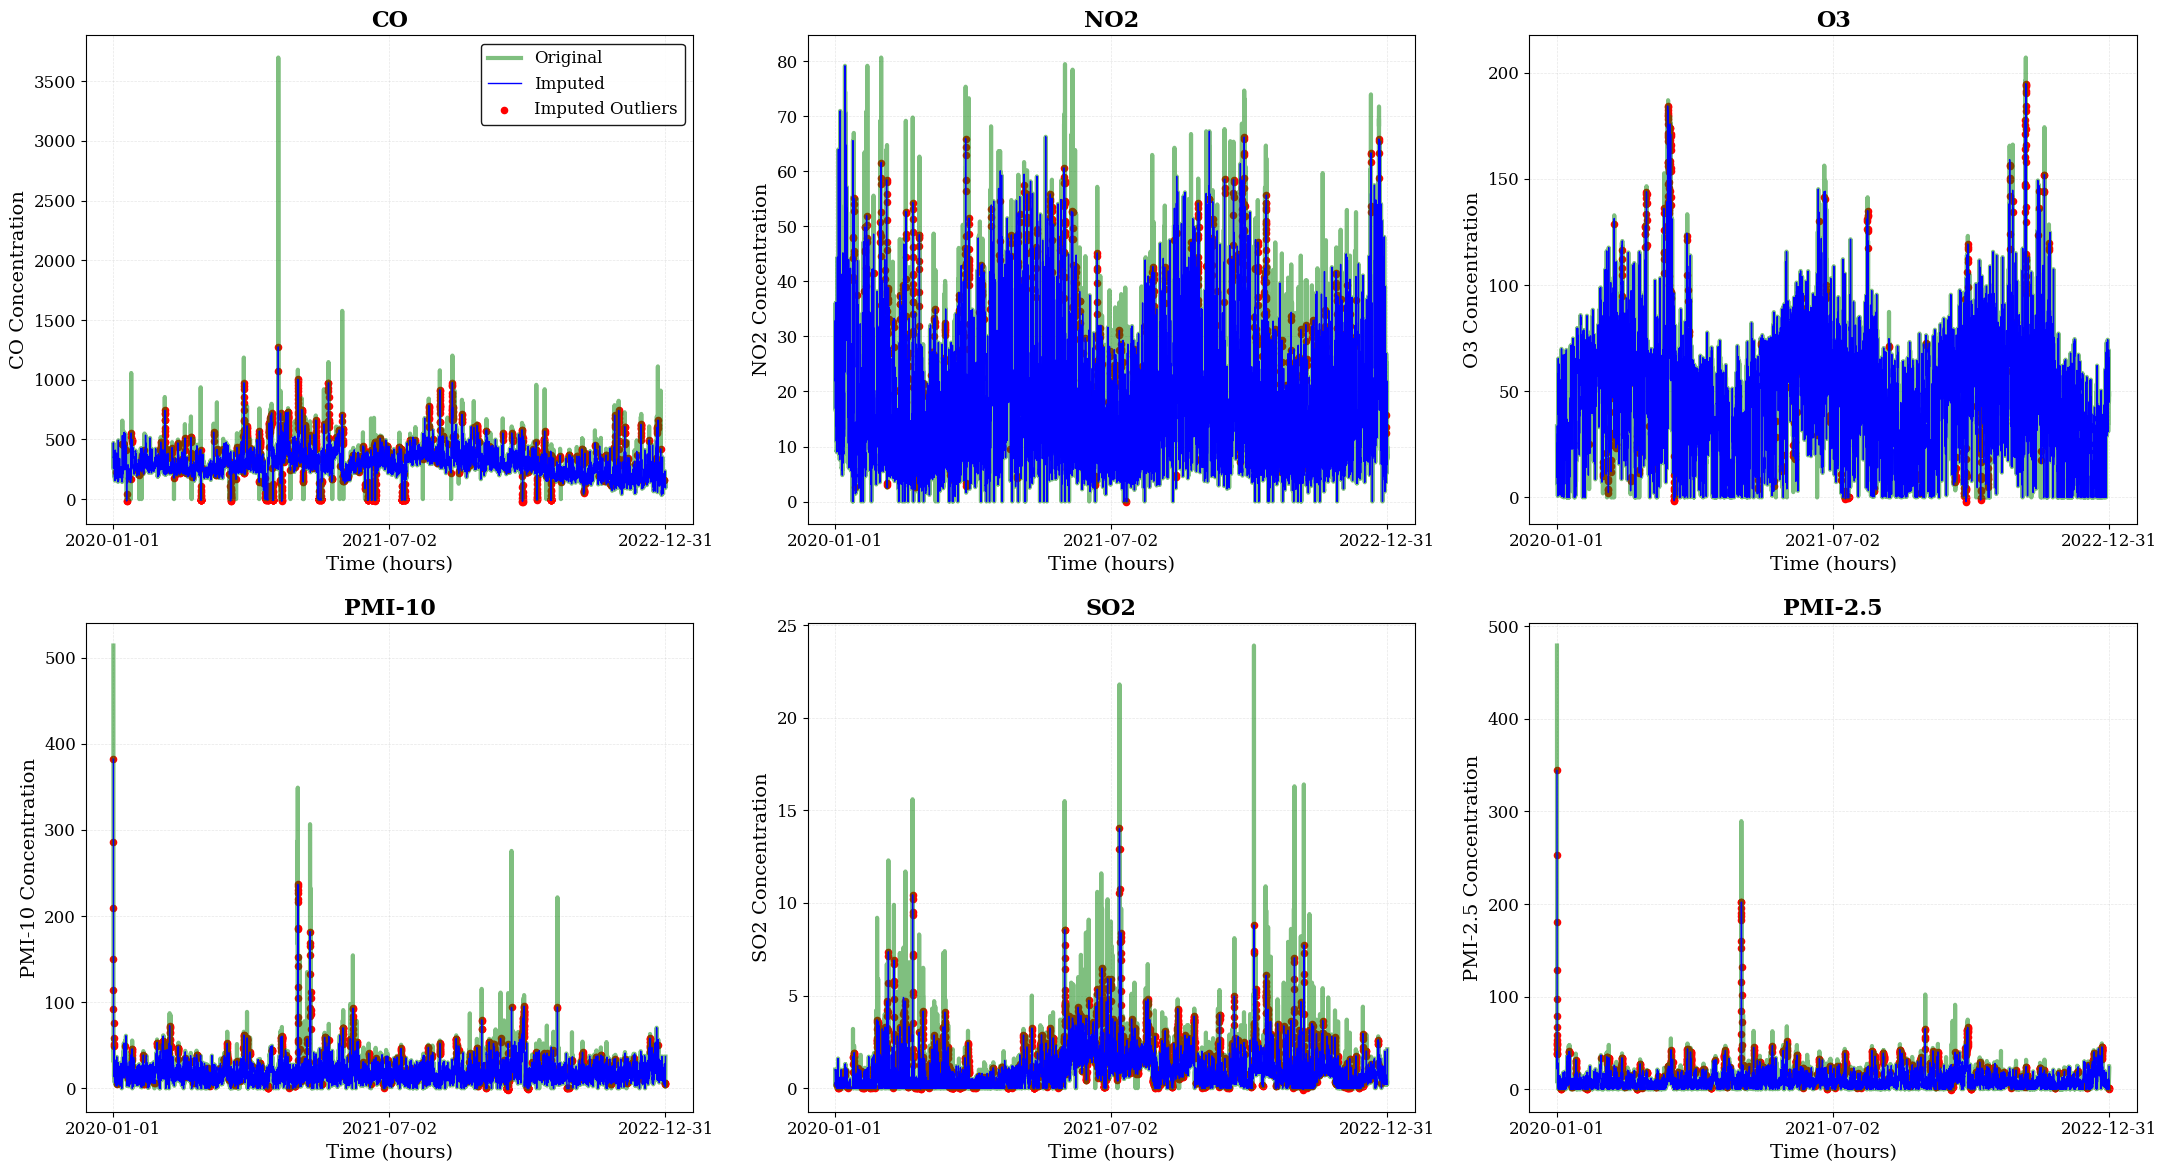

In [20]:
cols = ['CO', 'NO2', 'O3', 'PMI-10', 'SO2', 'PMI-2.5']
imputation_plot = plot_imputation_grid(df, cols)
# plt.savefig("figures/imputation_plot.png", dpi=300, bbox_inches='tight')
# # plot_imputation(df, "CO") #

In [21]:
df.columns

Index(['CO', 'NO2', 'O3', 'PMI-10', 'SO2', 'PMI-2.5', 'hour', 'day_of_week',
       'month', 'Weekend', 'is_holiday', 'season', 'CO_trend', 'CO_seasonal',
       'CO_resid', 'outlier_CO', 'CO_imputed', 'NO2_trend', 'NO2_seasonal',
       'NO2_resid', 'outlier_NO2', 'NO2_imputed', 'O3_trend', 'O3_seasonal',
       'O3_resid', 'outlier_O3', 'O3_imputed', 'PMI-10_trend',
       'PMI-10_seasonal', 'PMI-10_resid', 'outlier_PMI-10', 'PMI-10_imputed',
       'SO2_trend', 'SO2_seasonal', 'SO2_resid', 'outlier_SO2', 'SO2_imputed',
       'PMI-2.5_trend', 'PMI-2.5_seasonal', 'PMI-2.5_resid', 'outlier_PMI-2.5',
       'PMI-2.5_imputed'],
      dtype='object')

In [20]:
df["CO_imputed"].head(4) #print this so when unnecessary colunms are 
#drop, you can confirm that the renaming exercise truly happens..

Timestamp
2020-01-01 00:00:00    263.1
2020-01-01 01:00:00    337.0
2020-01-01 02:00:00    471.0
2020-01-01 03:00:00    387.9
Name: CO_imputed, dtype: float64

In [22]:
keepcolumns = ['CO_imputed', 'O3_imputed', 'NO2_imputed',
       'PMI-10_imputed', 'SO2_imputed', 'PMI-2.5_imputed','hour', 'day_of_week',
       'month', 'Weekend', 'is_holiday', 'season']

In [23]:
mydit = df[keepcolumns]  # keep only the necessary columns..
mydit.columns

Index(['CO_imputed', 'O3_imputed', 'NO2_imputed', 'PMI-10_imputed',
       'SO2_imputed', 'PMI-2.5_imputed', 'hour', 'day_of_week', 'month',
       'Weekend', 'is_holiday', 'season'],
      dtype='object')

In [ ]:
mydit.rename(columns={"CO_imputed": "CO", "O3_imputed": "O3", 
                      "NO2_imputed": "NO2", "PMI-10_imputed":"PM-10",
                        "SO2_imputed": "SO2", "PMI-2.5_imputed":"PMI-2.5"}, inplace=True)

In [25]:
print(mydit["CO"].head(4)) # indeed, it  comfirm
print(mydit.columns.to_list) # get and confirm all the columns.. 

Timestamp
2020-01-01 00:00:00    263.1
2020-01-01 01:00:00    337.0
2020-01-01 02:00:00    471.0
2020-01-01 03:00:00    387.9
Name: CO, dtype: float64
<bound method IndexOpsMixin.tolist of Index(['CO', 'O3', 'NO2', 'PM-10', 'SO2', 'PMI-2.5', 'hour', 'day_of_week',
       'month', 'Weekend', 'is_holiday', 'season'],
      dtype='object')>


## Exploration Data Analysis.. 

In [26]:
mydit["is_holiday"]

Timestamp
2020-01-01 00:00:00    1
2020-01-01 01:00:00    1
2020-01-01 02:00:00    1
2020-01-01 03:00:00    1
2020-01-01 04:00:00    1
                      ..
2022-12-31 19:00:00    0
2022-12-31 20:00:00    0
2022-12-31 21:00:00    0
2022-12-31 22:00:00    0
2022-12-31 23:00:00    0
Name: is_holiday, Length: 26304, dtype: int64

In [18]:
ai.plt.rcParams['font.family'] = 'serif' # Set the plotting paramters
ai.plt.rcParams['font.size'] = 12 

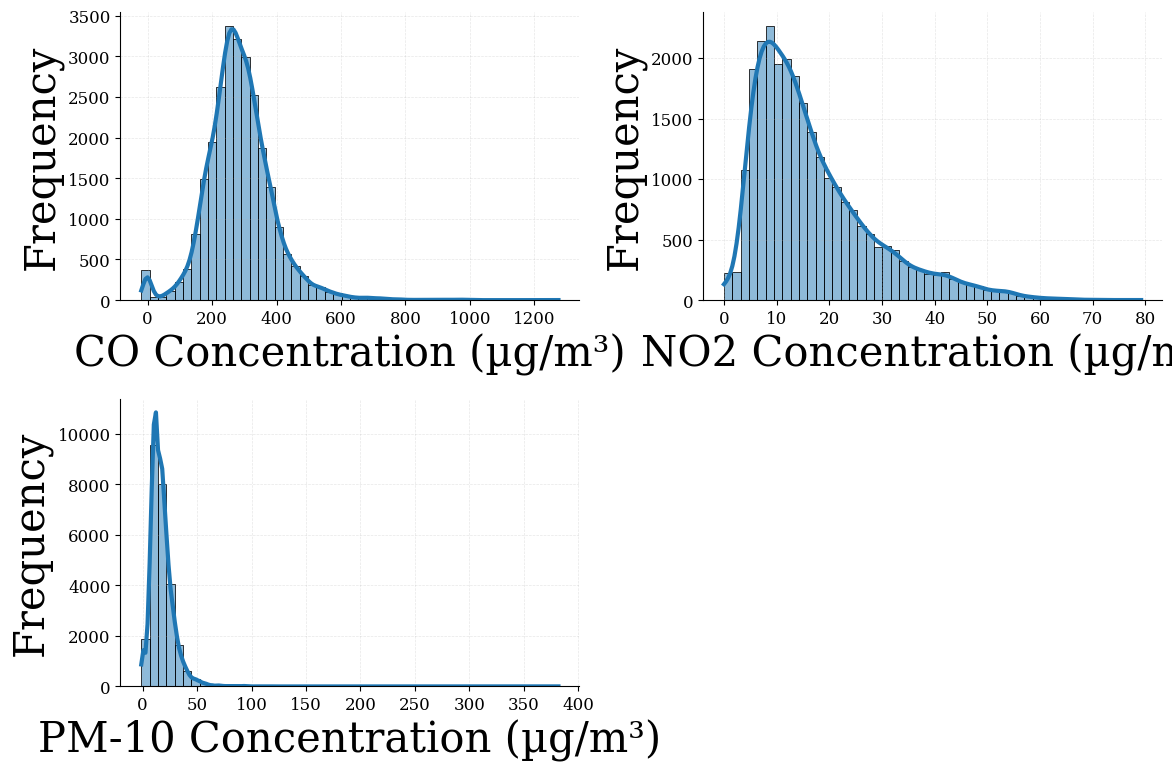

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

def d_subplots(data, columns, ncols=2):
    n = len(columns)
    nrows = (n + ncols - 1) // ncols  # Ceiling division for rows

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
    axes = axes.flatten()  # Flatten in case of multiple rows

    for i, col in enumerate(columns):
        sns.histplot(data[col], kde=True, bins=50, color='tab:blue', ax=axes[i])
        # axes[i].set_title(f"Distribution of {col} Concentration", fontsize=14)
        axes[i].set_xlabel(f"{col} Concentration (µg/m³)", fontsize=30)
        axes[i].set_ylabel("Frequency", fontsize=30)
        axes[i].grid(True, linestyle='--', alpha=0.3)
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    # plt.show()
numcol = ['CO', 'NO2', 'PM-10']
ditplot = d_subplots(mydit, numcol, ncols=2)
# plt.savefig("figures/ditplot.png", dpi=300, bbox_inches='tight')


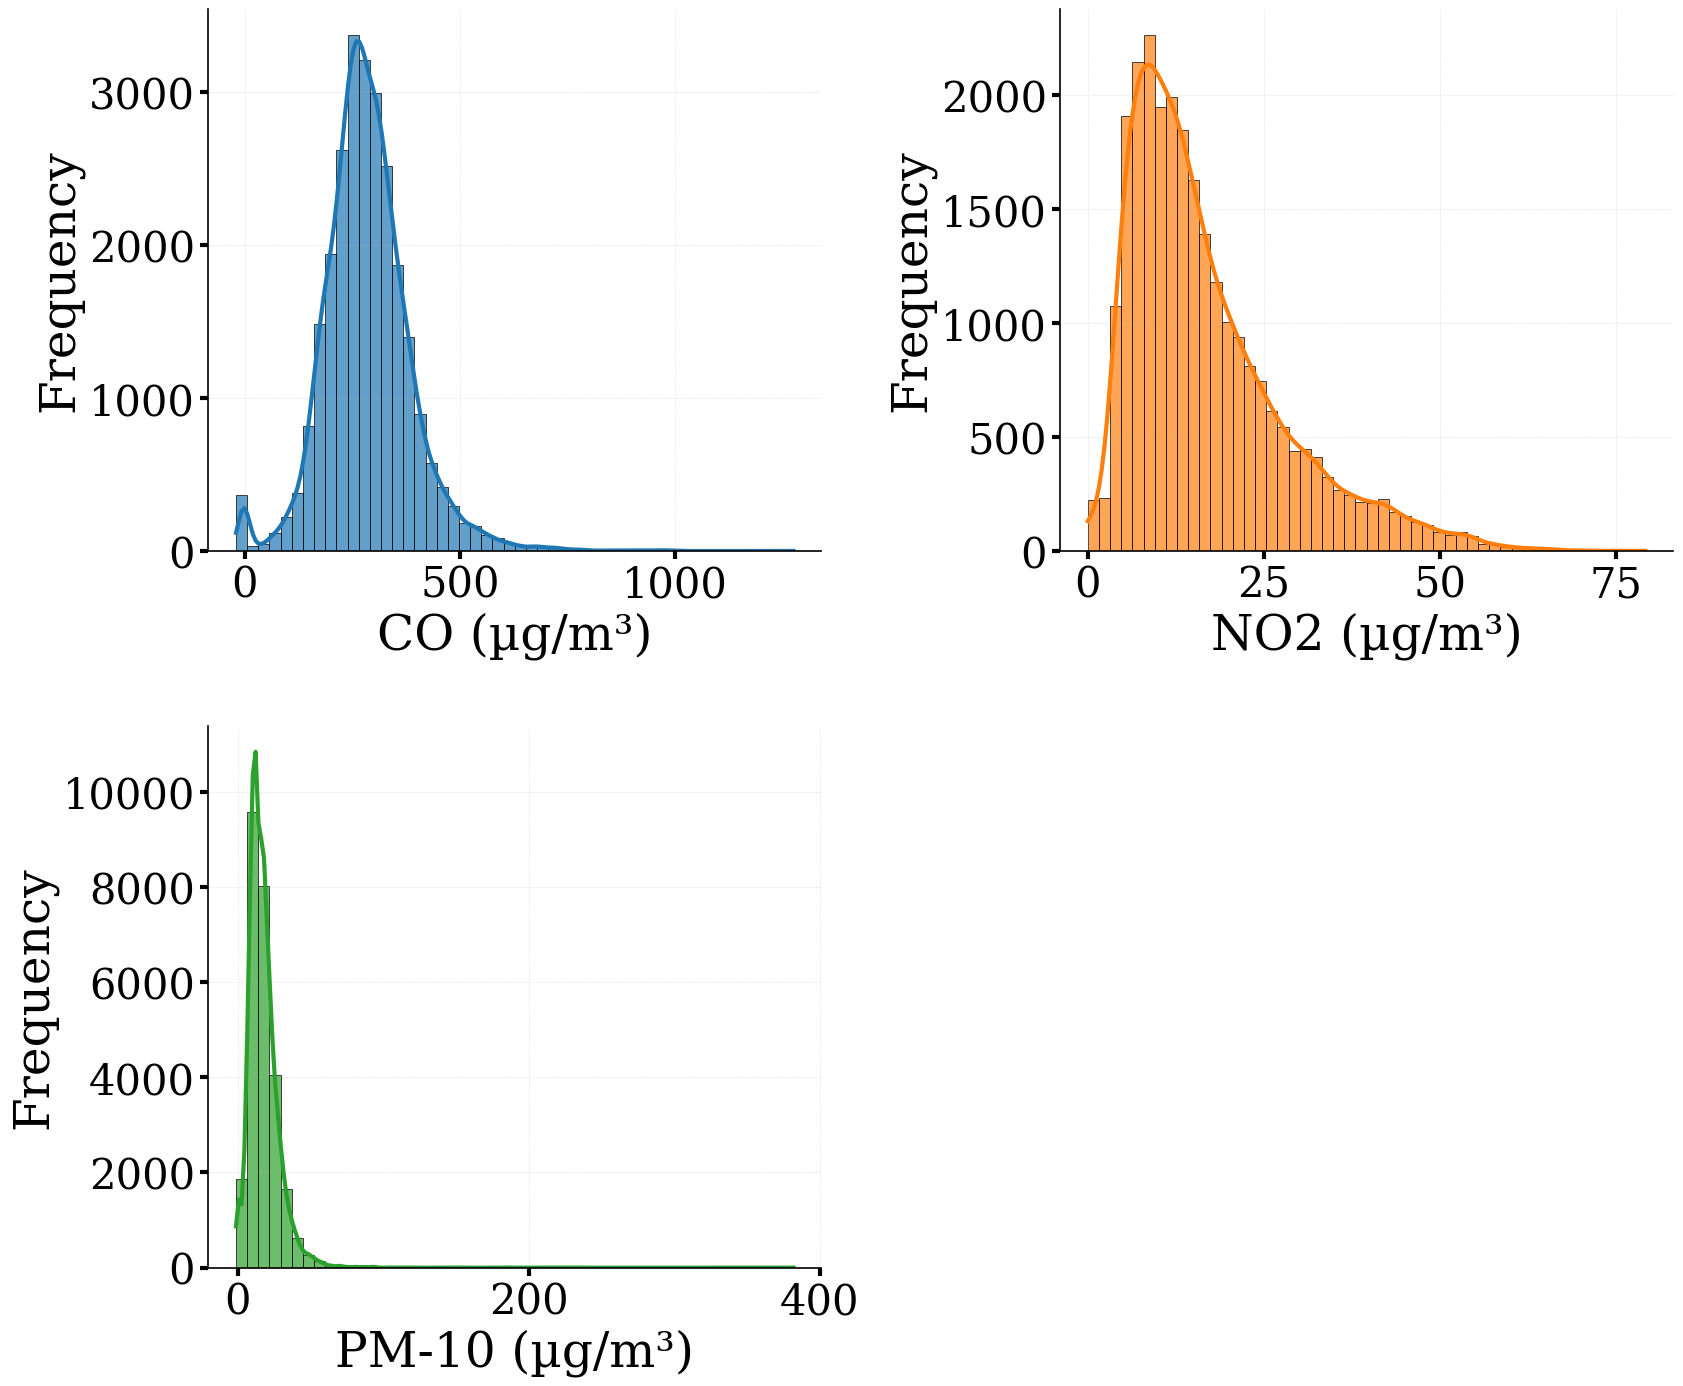

In [28]:
def d_subplots(data, columns, ncols=2):
    n = len(columns)
    nrows = (n + ncols - 1) // ncols  # Ceiling division for rows

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 15))
    axes = axes.flatten() if n > 1 else [axes]  # Handle single subplot case

    # Define colors and styles for publication quality
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Professional color palette
    
    for i, col in enumerate(columns):
        sns.histplot(data[col], kde=True, bins=50, color=colors[i % len(colors)], 
                    alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[i])
        
        # Publication-quality formatting
        axes[i].set_xlabel(f"{col} (µg/m³)", fontsize=35, fontweight='normal')
        axes[i].set_ylabel("Frequency", fontsize=35, fontweight='normal')
        
        # Apply the tick formatting you mentioned
        axes[i].tick_params(axis='both', labelsize=30, width=3, length=6)
        
        # Apply formatting to individual tick labels
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontsize(30)
            label.set_fontweight('normal')
            label.set_rotation(0)
        
        axes[i].grid(True, linestyle='--', alpha=0.3)
        
        # Clean spines for publication
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].spines['left'].set_linewidth(1.2)
        axes[i].spines['bottom'].set_linewidth(1.2)

    # Hide any unused subplots
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(pad=3.0)
    plt.savefig('pollutant_distributions.pdf', dpi=600, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.show()
    
    return fig

# Usage
numcol = ['CO', 'NO2', 'PM-10']
ditplot = d_subplots(mydit, numcol, ncols=2)

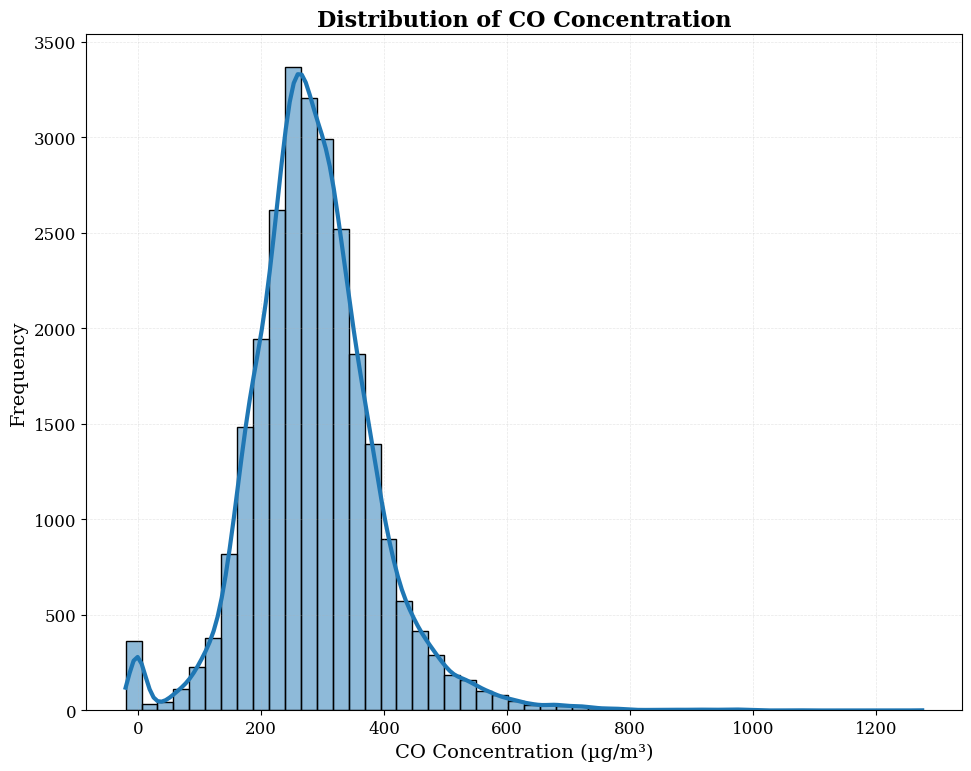

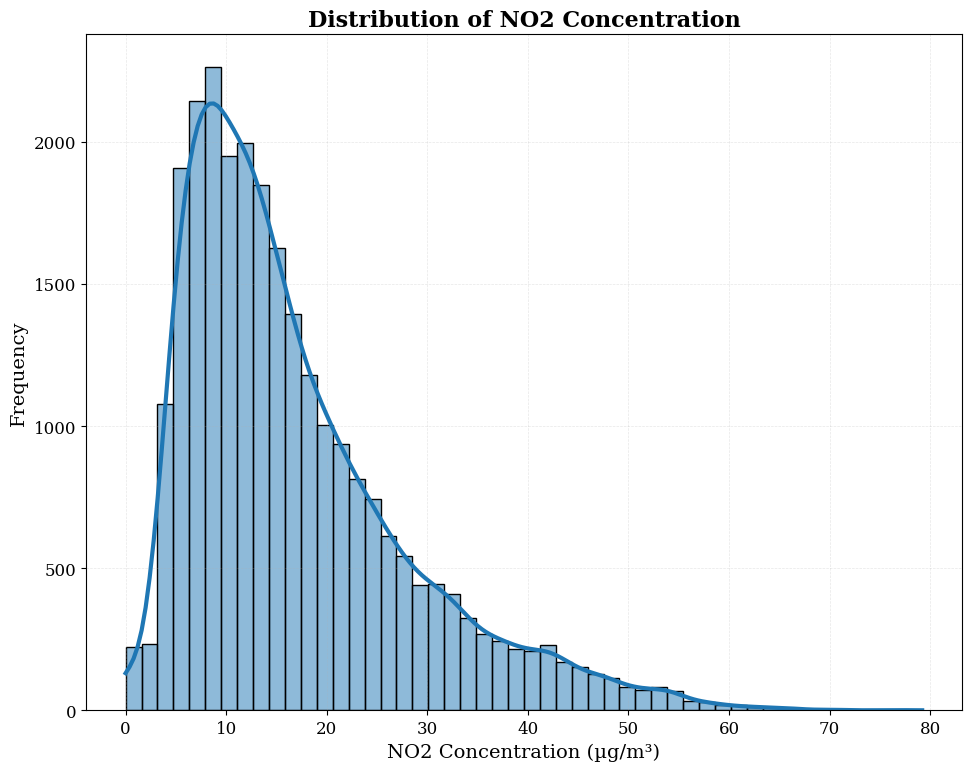

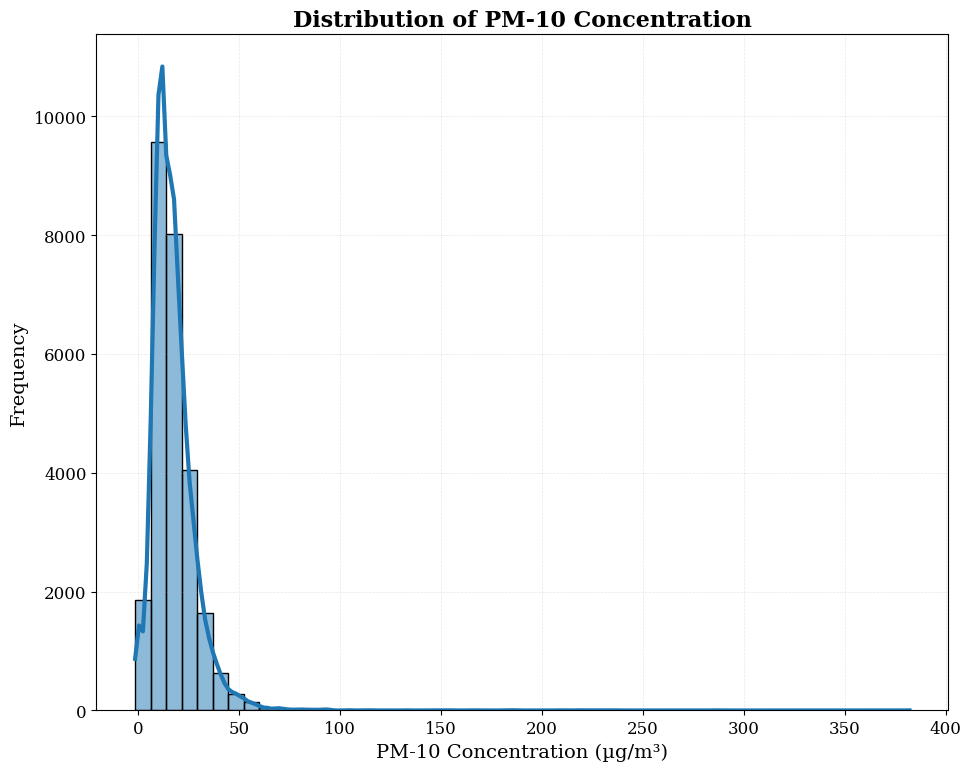

In [30]:
#understand the distribution of eac pollutants on individual plots..
def dirstibution_plot(data, col):
    plt.figure(figsize=(10, 8))
    sns.histplot(data[col], kde=True, bins=50, color='tab:blue')

    plt.title(f"Distribution of {col} Concentration", fontsize=16)
    plt.xlabel(f"{col} Concentration (µg/m³)", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()



numcol = ['CO', 'NO2','PM-10']
for col in numcol:
    dirstibution_plot(mydit, col)

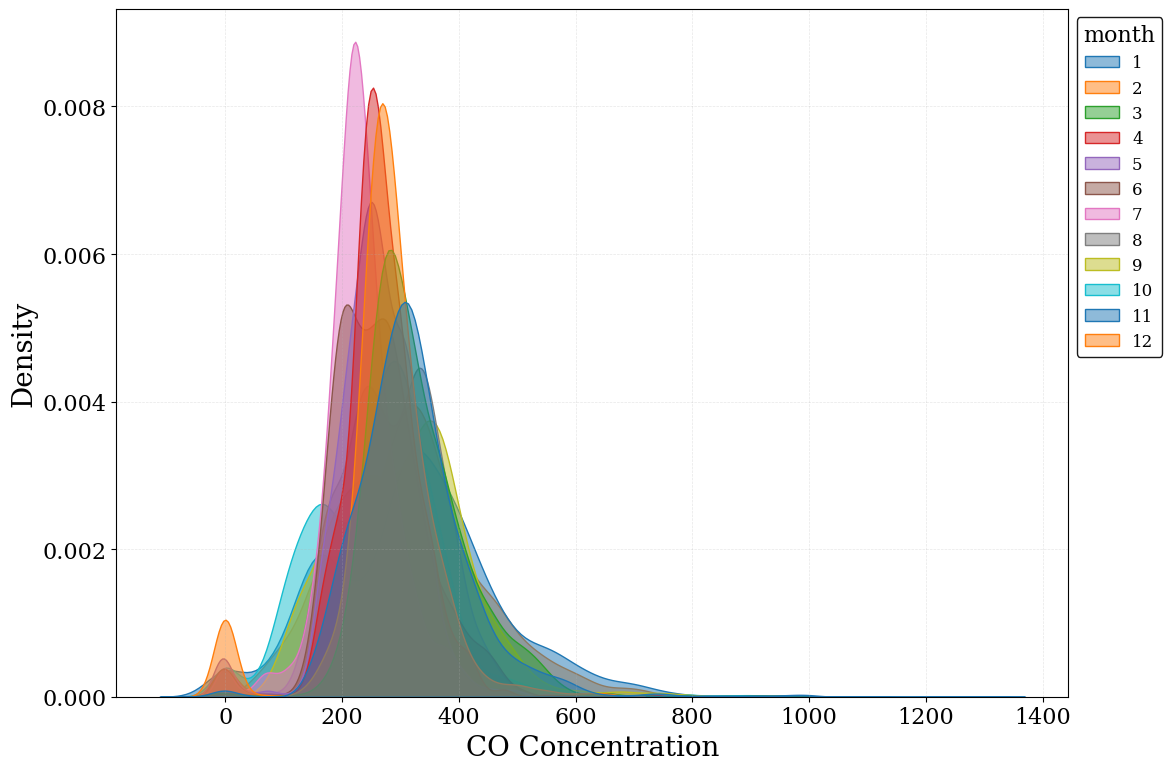

In [31]:
plt.figure(figsize=(12,8)) 


ax = sns.kdeplot(
   data=mydit, x='CO', hue="month",
   fill=True, common_norm=False, palette="tab10",
   alpha=.5, linewidth=1
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

ax.xaxis.tick_bottom()
ax.yaxis.tick_left()
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=16)
ax.set_xlabel('CO Concentration',  fontsize = 20)
ax.set_ylabel('Density',  fontsize = 20)
plt.show()

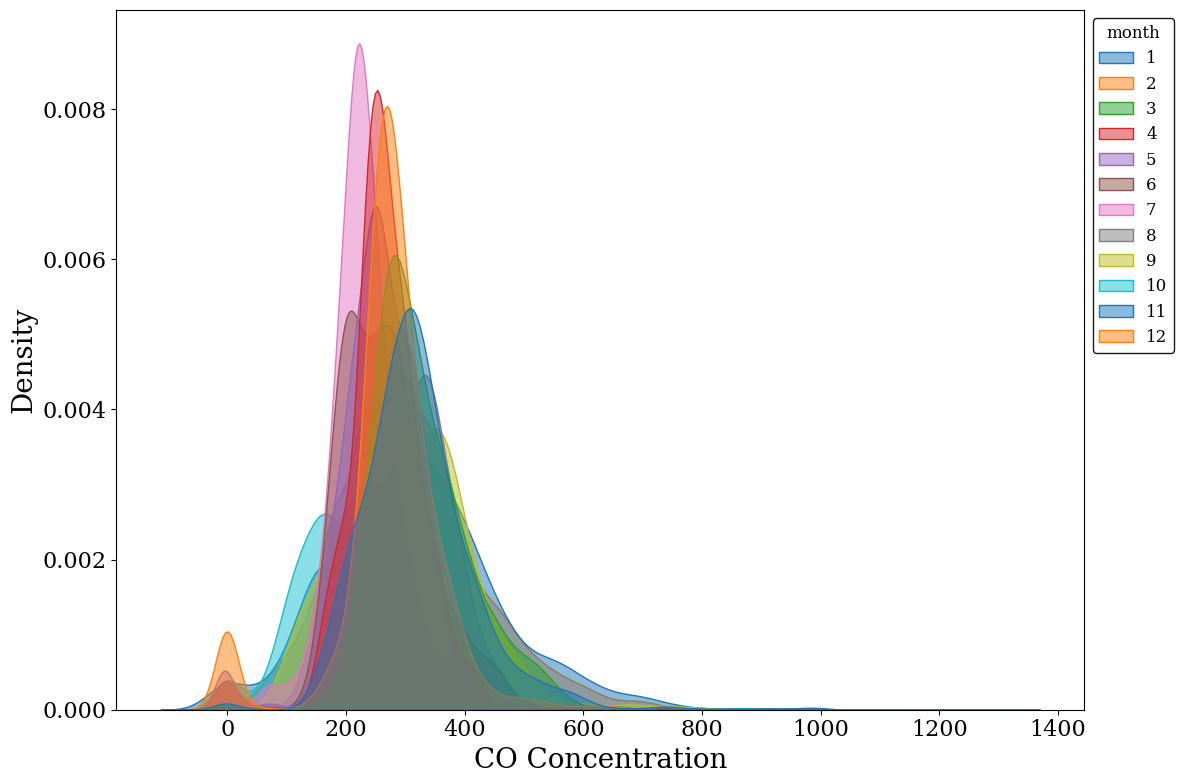

In [32]:

# Set global plot style
plt.figure(figsize=(12, 8))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

# KDE plot
ax = sns.kdeplot(
    data=mydit, x='CO', hue='month',
    fill=True, common_norm=False, palette='tab10',
    alpha=0.5, linewidth=1
)

# Axis labels
plt.xlabel('CO Concentration', fontsize=20)
plt.ylabel('Density', fontsize=20)

# Legend positioning
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

# Tick styling
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=16)
ax.xaxis.tick_bottom()
ax.yaxis.tick_left()

# Remove grid and set white background
ax.grid(False)
ax.set_facecolor('white')  # axes background
plt.gcf().patch.set_facecolor('white')  # figure background

# Final layout
plt.tight_layout()
plt.show()

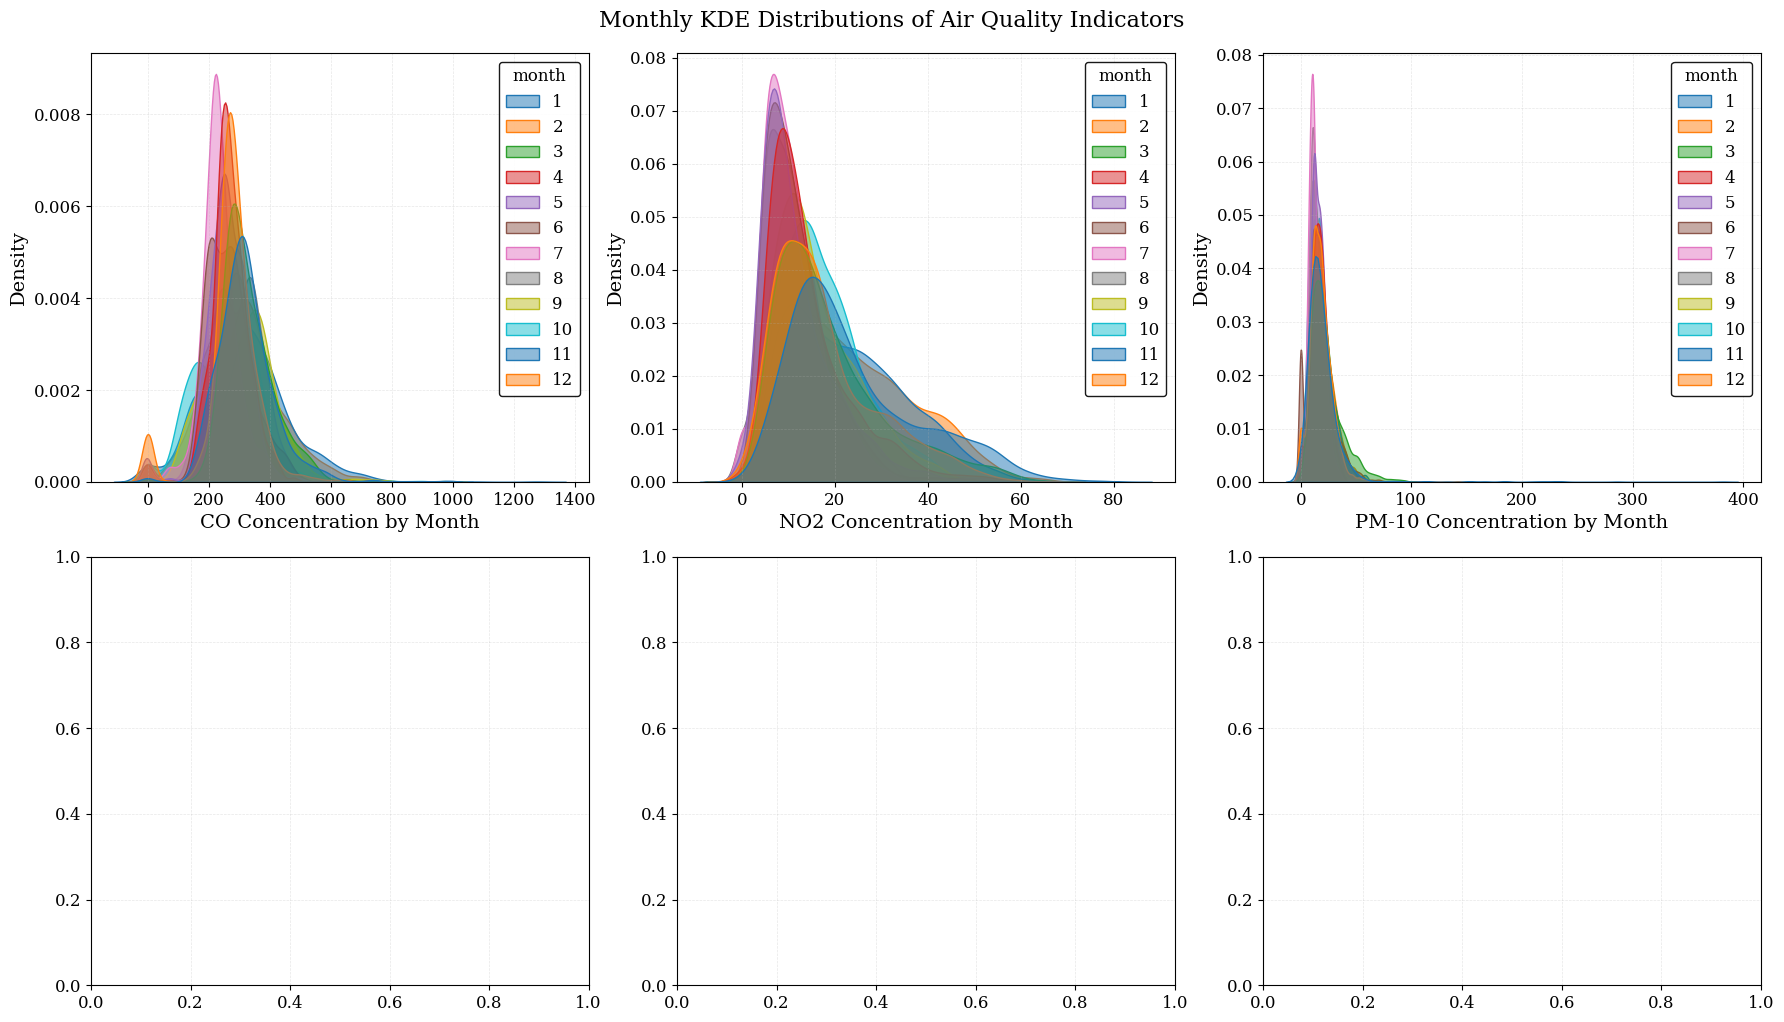

In [33]:

indicators = ["CO", "NO2", "PM-10"]
n = len(indicators)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(indicators):
    sns.kdeplot(data=mydit, x=col, hue="month", ax=axes[i], common_norm=False, palette="tab10", fill=True, alpha=0.5, linewidth=1)
    axes[i].set_xlabel(col + " Concentration by Month")
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.suptitle("Monthly KDE Distributions of Air Quality Indicators", fontsize=16, y=1.02)
plt.show()

In [70]:
mydit.columns

Index(['CO', 'O3', 'NO2', 'PMI-10', 'SO2', 'PMI-2.5', 'hour', 'day_of_week',
       'month', 'Weekend', 'is_holiday', 'season'],
      dtype='object')

In [38]:
#plot the correlations analysis and see how each pollutant relates to each other 
def correlation_heatmap(data):
    numcol = ['CO', 'NO2', 'PM-10'] #Isolate the numeric columns.. 
    corr_matrix = data[numcol].corr()
    display(ai.pd.DataFrame(corr_matrix))
    # Creating a heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(corr_matrix, annot=True, fmt=".2f",  cmap="Reds", cbar=True, linecolor='black', linewidths=0.4, alpha = 1)
    ax.set(xlabel="", ylabel="")
    ax.xaxis.tick_bottom()
    ax.yaxis.tick_left()
    plt.title('Correlation Matrix of Air Quality Indicator')
    plt.show()


,CO,NO2,PM-10
CO,1.000000,0.524186,0.311622
NO2,0.524186,1.000000,0.389858
PM-10,0.311622,0.389858,1.000000


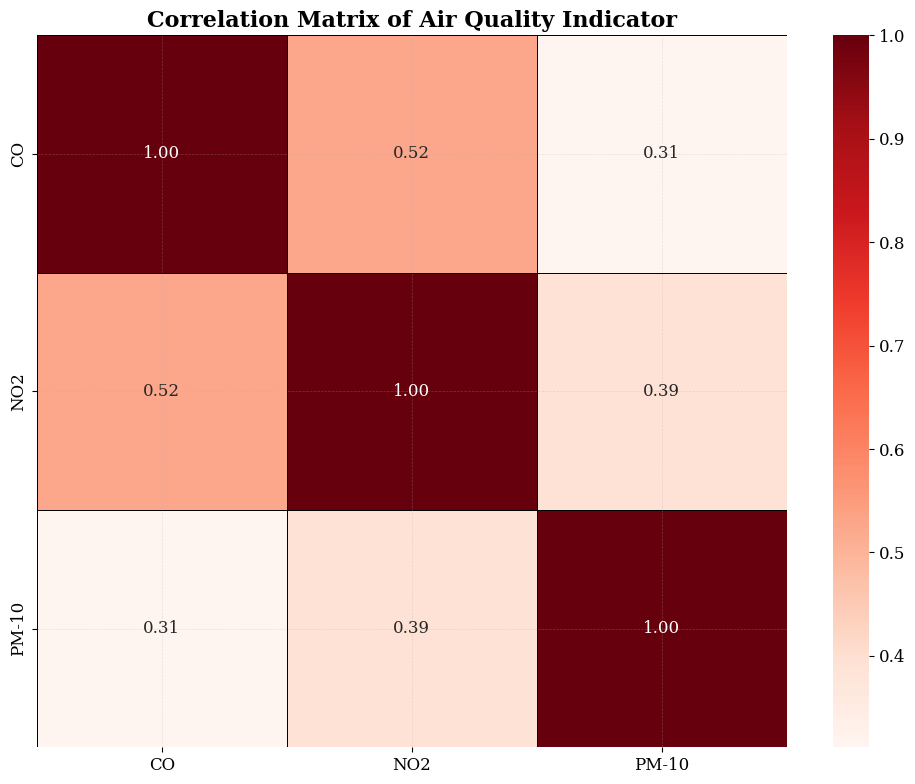

In [39]:
correlation_heatmap(mydit) # plot the correlation heatmap..

In [46]:
def seasonal_covariance_subplots(data):
    numcol = ['CO', 'NO2','PM-10']  # Numeric columns
    seasons = sorted(data['season'].unique())
    season_covs = {season: data[data['season'] == season][numcol].cov() for season in seasons}

    # Determine subplot grid size
    n = len(seasons)
    cols = 4
    rows = 1

    fig, axes = ai.plt.subplots(2, 2, figsize=(12, 5 * rows))
    axes = axes.flatten()

    for i, (season, cov_matrix) in enumerate(season_covs.items()):
        ax = axes[i]
        ai.sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt=".2f",
                    linewidths=0.5, ax=ax, cbar=False)
        ax.set_title(f"Covariance Matrix - {season}")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.xaxis.tick_bottom()
        ax.yaxis.tick_left()

    # Hide unused subplots if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    ai.plt.tight_layout()
    ai.plt.show()

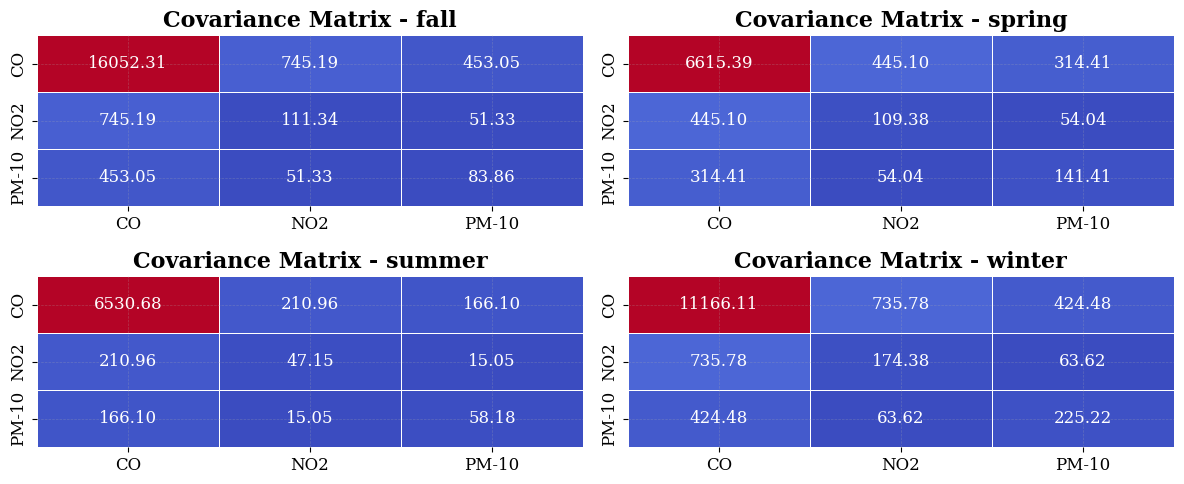

In [47]:
seasonal_covariance_subplots(mydit) 

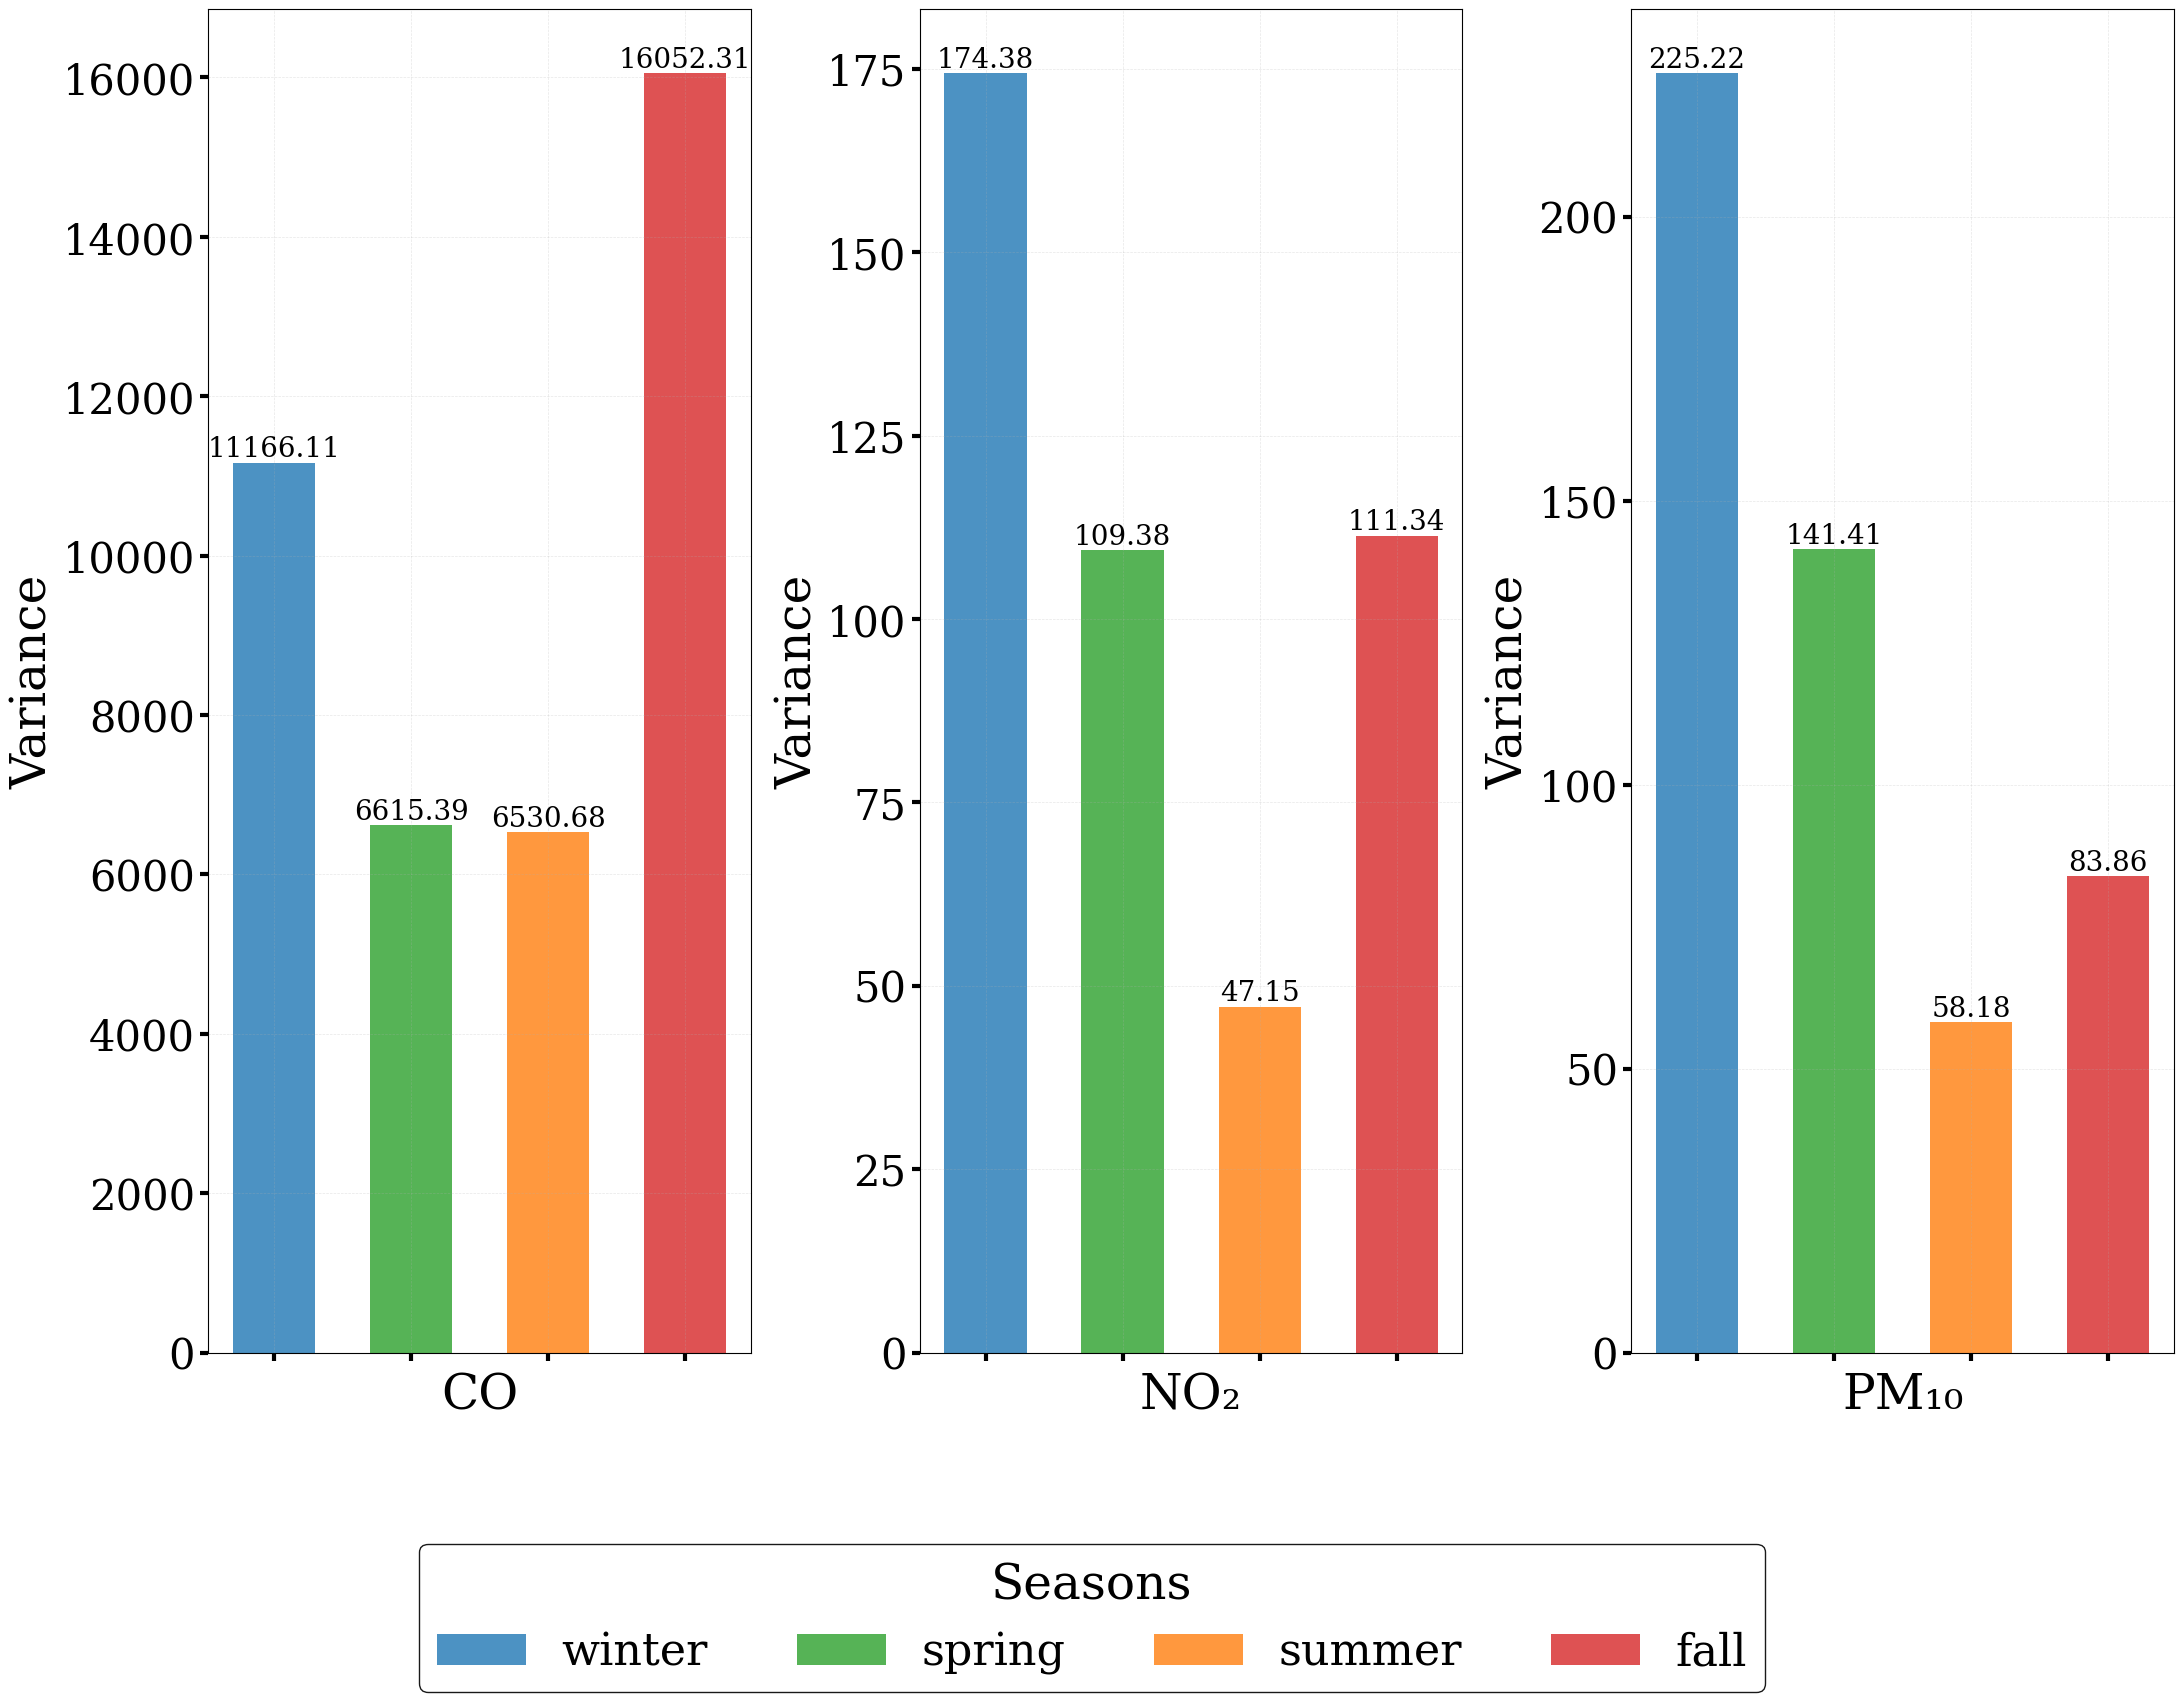

' this code extract the seasonal variances from the diagonal of the covraince matrix and plot them.. '

In [50]:
def seasonal_covariance_barplot(data, save_path=None, value_fontsize=20):
    numcol = ['CO', 'NO2', 'PM-10']  # Only 3 variables
    
    # Calculate seasonal covariance matrices
    season_covs = {}
    for season in data['season'].unique():
        subset = data[data['season'] == season][numcol]
        season_covs[season] = subset.cov()
    
    # Extract variances (diagonal elements) for bar plot
    seasonal_variances = {}
    for season, cov_matrix in season_covs.items():
        seasonal_variances[season] = np.diag(cov_matrix)
    
    # Define colors for each season
    season_colors = {
        'spring': '#2ca02c',    # Green
        'summer': '#ff7f0e',    # Orange
        'fall': '#d62728',    # Red
        'winter': '#1f77b4'     # Blue
    }
    
    # Font size settings
    tick_fontsize = 30
    tick_width = 3
    tick_length = 6
    
    # Create one subplot per variable
    fig, axes = ai.plt.subplots(1, 3, figsize=(22, 17))
    
    seasons = list(seasonal_variances.keys())
    x_pos = ai.np.arange(len(seasons))
    width = 0.6
    
    # Plot CO variances across all seasons
    co_variances = [seasonal_variances[season][0] for season in seasons]
    bars1 = axes[0].bar(x_pos, co_variances, width, alpha=0.8, 
                       color=[season_colors[season] for season in seasons])
    axes[0].set_xlabel('CO', fontsize=35, fontweight='normal')
    axes[0].set_ylabel('Variance', fontsize=35)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels([''] * len(seasons))
    
    # Plot NO2 variances across all seasons
    no2_variances = [seasonal_variances[season][1] for season in seasons]
    bars2 = axes[1].bar(x_pos, no2_variances, width, alpha=0.8,
                       color=[season_colors[season] for season in seasons])
    axes[1].set_xlabel('NO₂', fontsize=35, fontweight='normal')
    axes[1].set_ylabel('Variance', fontsize=35)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([''] * len(seasons))
    
    # Plot PM10 variances across all seasons
    pm10_variances = [seasonal_variances[season][2] for season in seasons]
    bars3 = axes[2].bar(x_pos, pm10_variances, width, alpha=0.8,
                       color=[season_colors[season] for season in seasons])
    axes[2].set_xlabel('PM₁₀', fontsize=35, fontweight='normal')
    axes[2].set_ylabel('Variance', fontsize=35)
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels([''] * len(seasons))
    
    # Add value labels on bars with adjustable fontsize
    for bars, ax in zip([bars1, bars2, bars3], axes):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=value_fontsize)
    
    # Apply tick formatting to all axes
    for ax in axes:
        ax.tick_params(axis='both', labelsize=tick_fontsize, width=tick_width, length=tick_length)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(tick_fontsize)
            label.set_fontweight('normal')
            label.set_rotation(0)
    
    # Create custom legend with larger size
    legend_elements = [ai.plt.Rectangle((0,0), 1, 1, facecolor=season_colors[season], alpha=0.8)
                      for season in seasons]
    fig.legend(legend_elements, seasons, 
               title='Seasons', loc='upper center', 
               bbox_to_anchor=(0.5, 0.05), ncol=4, 
               fontsize=32, title_fontsize=35)
    
    ai.plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    if save_path:
        ai.plt.savefig(f"{save_path}.pdf", format='pdf', bbox_inches='tight', dpi=600)
    ai.plt.show()
    
    return seasonal_variances

# Usage examples with different value sizes:
seasonal_variances = seasonal_covariance_barplot(mydit,value_fontsize=20)  # Larger values


''' this code extract the seasonal variances from the diagonal of the covraince matrix and plot them.. '''

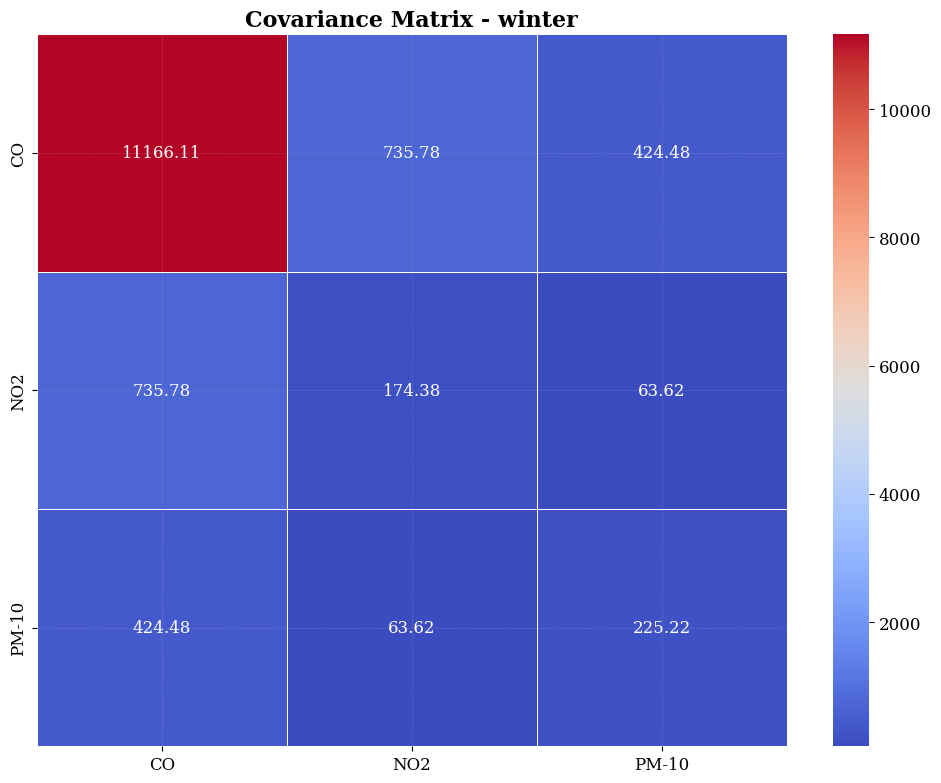

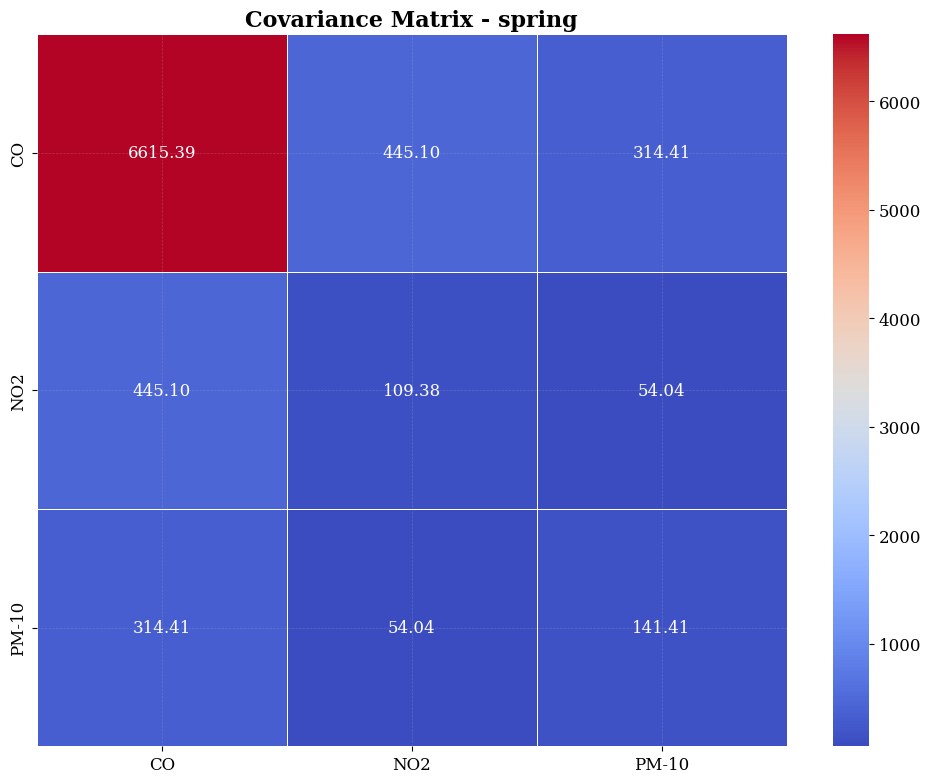

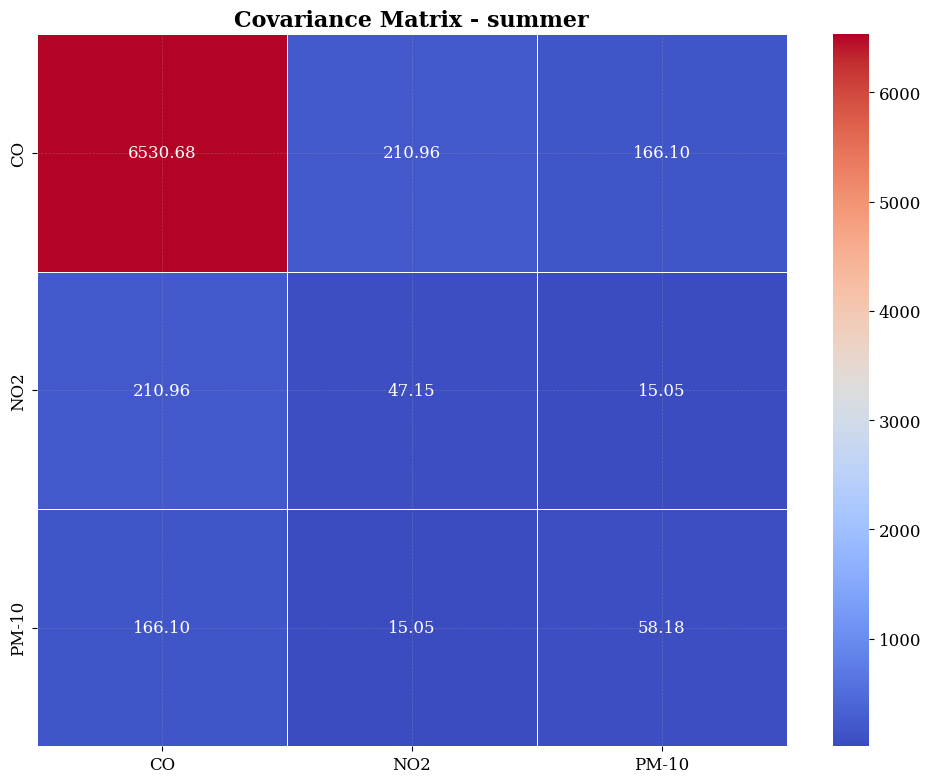

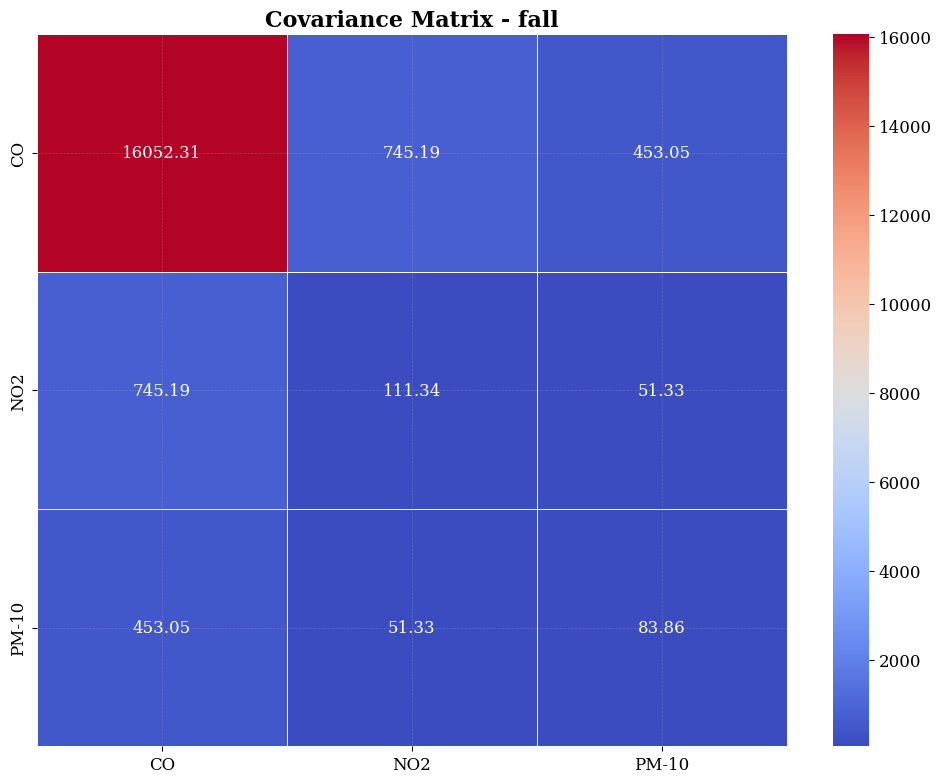

In [51]:

# Step 2: Compute seasonal covariance
def seasonal_covariance(data):
    numcol = ['CO', 'NO2','PM-10'] #Isolate the numeric columns.. 
    season_covs = {}
    for season in data['season'].unique():
        subset = data[data['season'] == season][numcol]
        season_covs[season] = subset.cov()
  
    for season, cov_matrix in season_covs.items():
        plt.figure(figsize=(10, 8))
        ax = sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
        ax.set(xlabel="", ylabel="")
        ax.xaxis.tick_bottom()
        ax.yaxis.tick_left()
  
        plt.title(f"Covariance Matrix - {season}")
        plt.show()


    
# Step 3: Visualize each season's covariance matrix
seasonal_covariance(mydit)

In [53]:
#plot the daily trend of each pollutant..
# Aggregate daily mean
def daily_trand(data, col):
    data = data.copy()
    # data['day_of_year'] = data.index.dayofyear
    daily_trend = data.groupby('day_of_week')[col].mean().reset_index()
    plt.figure(figsize=(12, 7))
    plt.plot(daily_trend['day_of_week'], daily_trend[col], marker='o', color='tab:blue', linewidth=2)
    plt.title(f"Daily {col} Concentration Trend Across the day", fontsize=16)
    plt.xlabel("Days of the Week", fontsize=14)
    plt.ylabel(f"{col} Concentration (µg/m³)", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

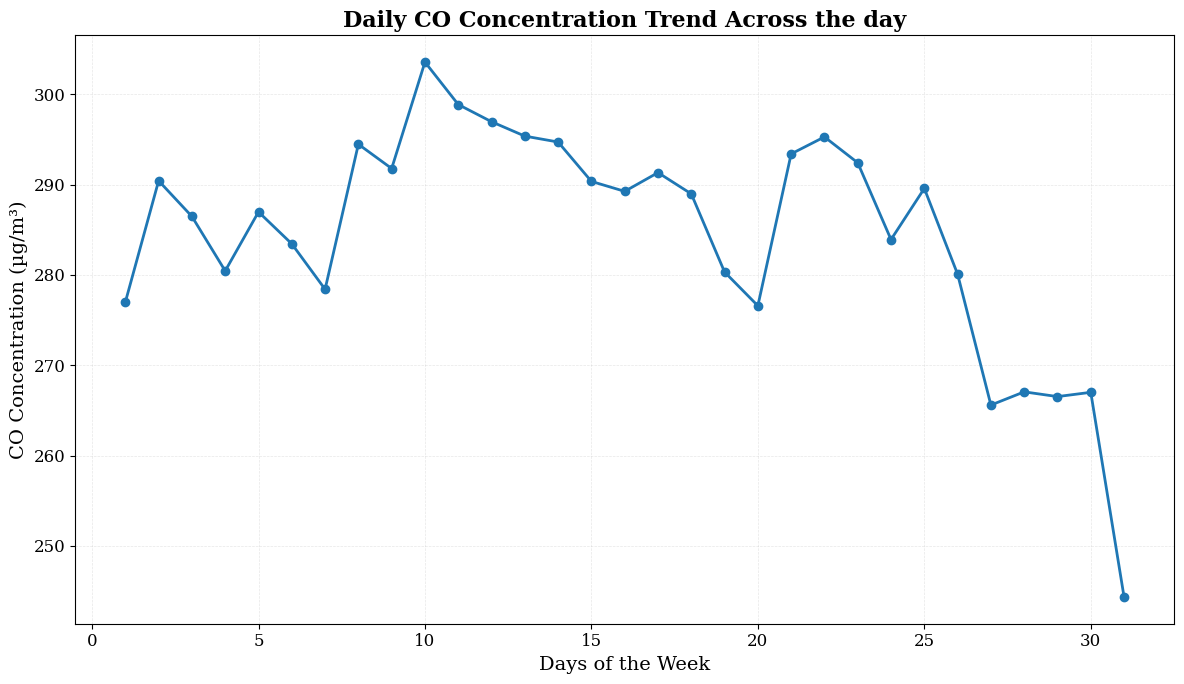

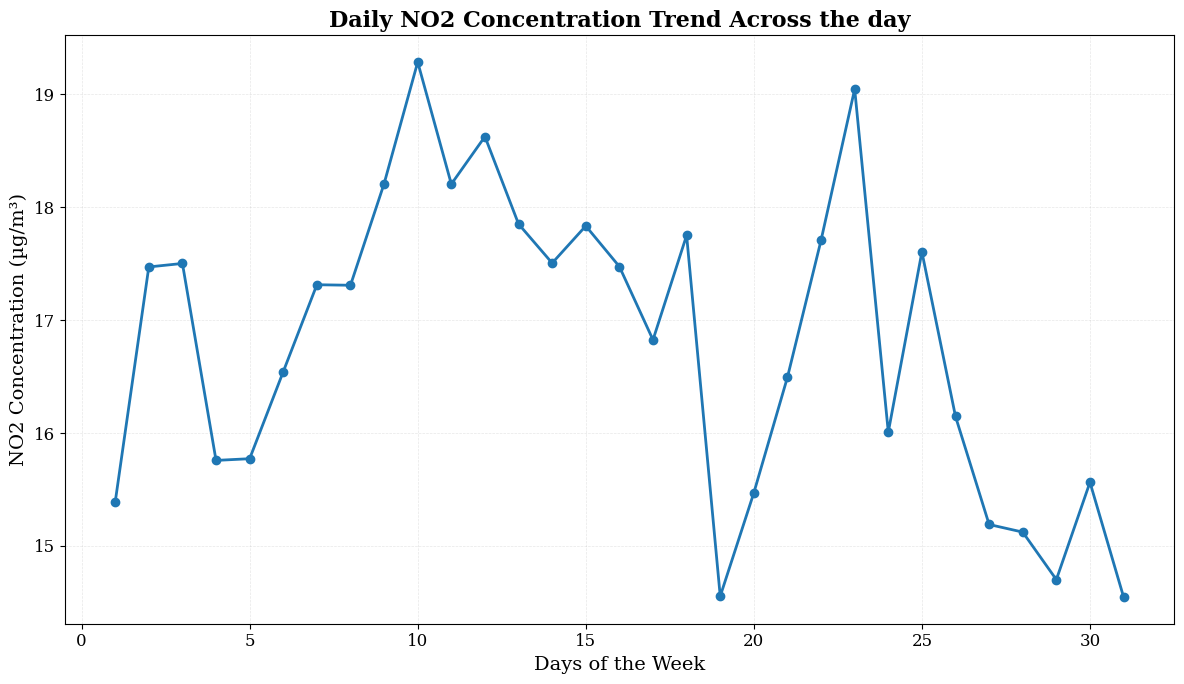

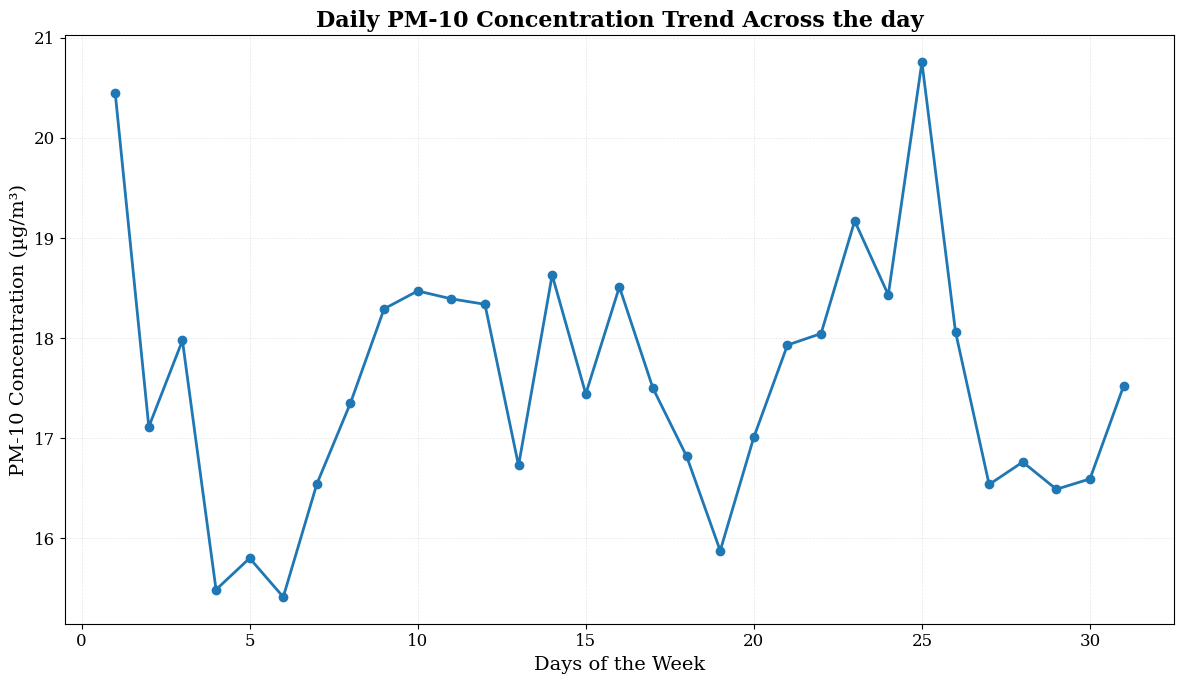

In [56]:
numcol = ['CO', "NO2", 'PM-10']
for col in numcol:
   daily_trand(mydit, col)

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

def monthly_trend_subplots(data, cols):
    data = data.copy()
    months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                    'July', 'August', 'September', 'October', 'November', 'December']
    data['month'] = ai.pd.Categorical(data.index.month_name(), categories=months_order, ordered=True)

    # n = len(cols)
    # rows = (n + 1) // 2
    fig, axes = ai.plt.subplots(1, 3, figsize=(16, 5 * 1))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        monthly_avg = data.groupby('month')[col].mean().reset_index()
        ax = axes[i]
        ax.plot(monthly_avg['month'], monthly_avg[col], marker='o', color='tab:green', linewidth=2)
        # ax.set_title(f"Average Monthly {col} Concentration", fontsize=14)
        ax.set_xlabel("Month", fontsize=12)
        ax.set_ylabel(f"{col} (µg/m³)", fontsize=12)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, linestyle='--', alpha=0.3)

    # Hide unused subplots if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    ai.plt.tight_layout()
    ai.plt.show()

In [ ]:

numcol = ['CO', 'NO2', 'PM-10']


monthly_trend_subplots(mydit, numcol)

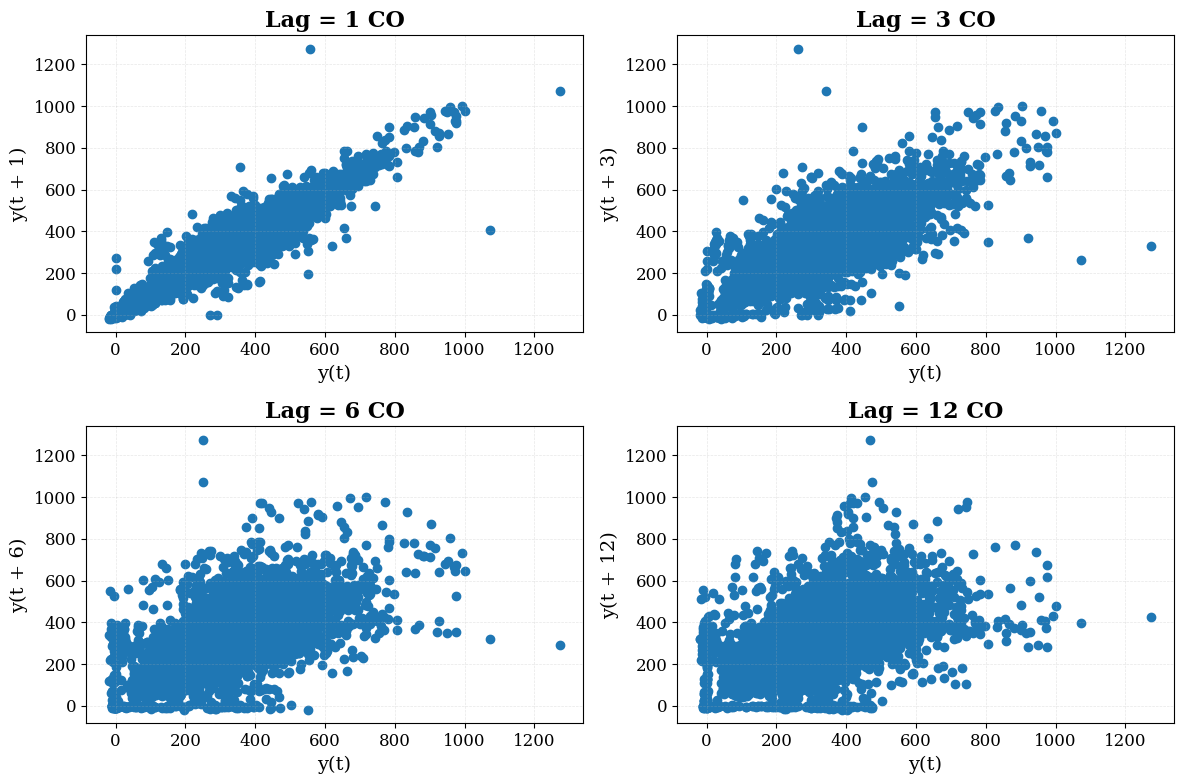

In [61]:

def plot_lag_plots(data, col, lags=[1, 3, 6, 12]):
    plt.figure(figsize=(12, 8))
    for i, lag in enumerate(lags):
        plt.subplot(2, 2, i+1)
        ai.lag_plot(data[col], lag=lag)
        plt.title(f"Lag = {lag} {col}")
    plt.tight_layout()
    plt.show()
plot_lag_plots(mydit, "CO", lags=[1, 3, 6, 12])

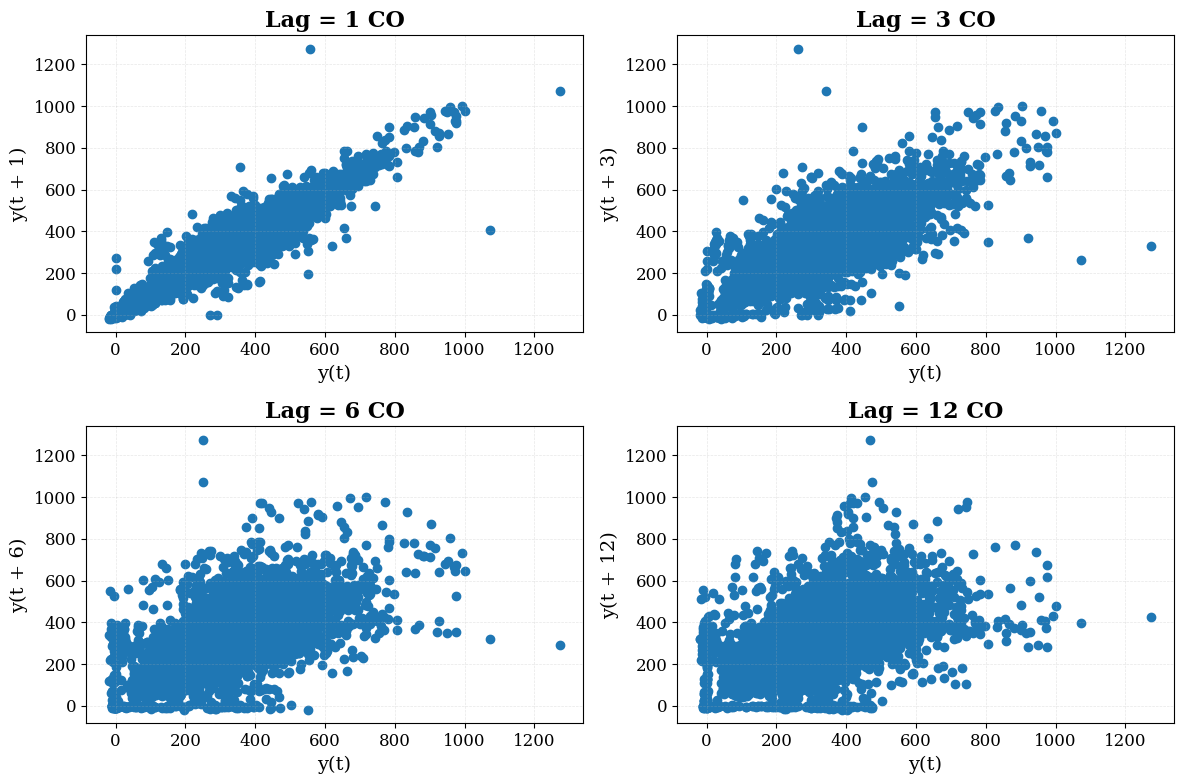

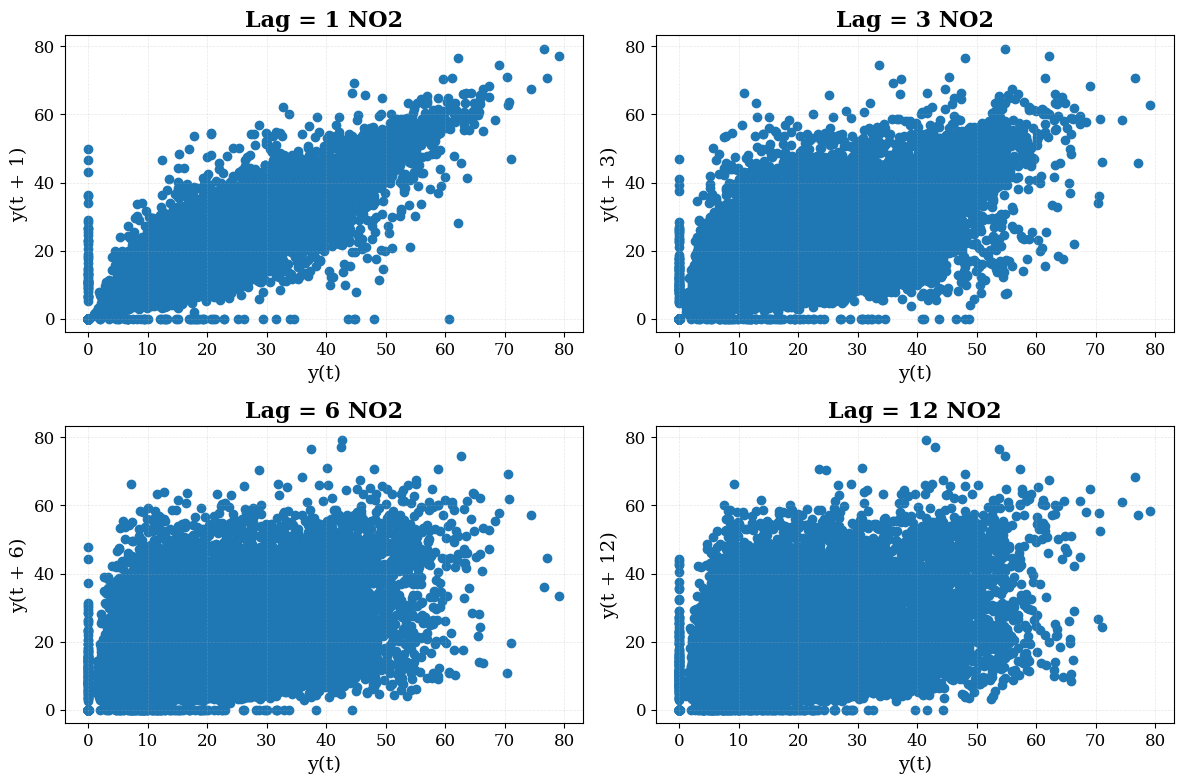

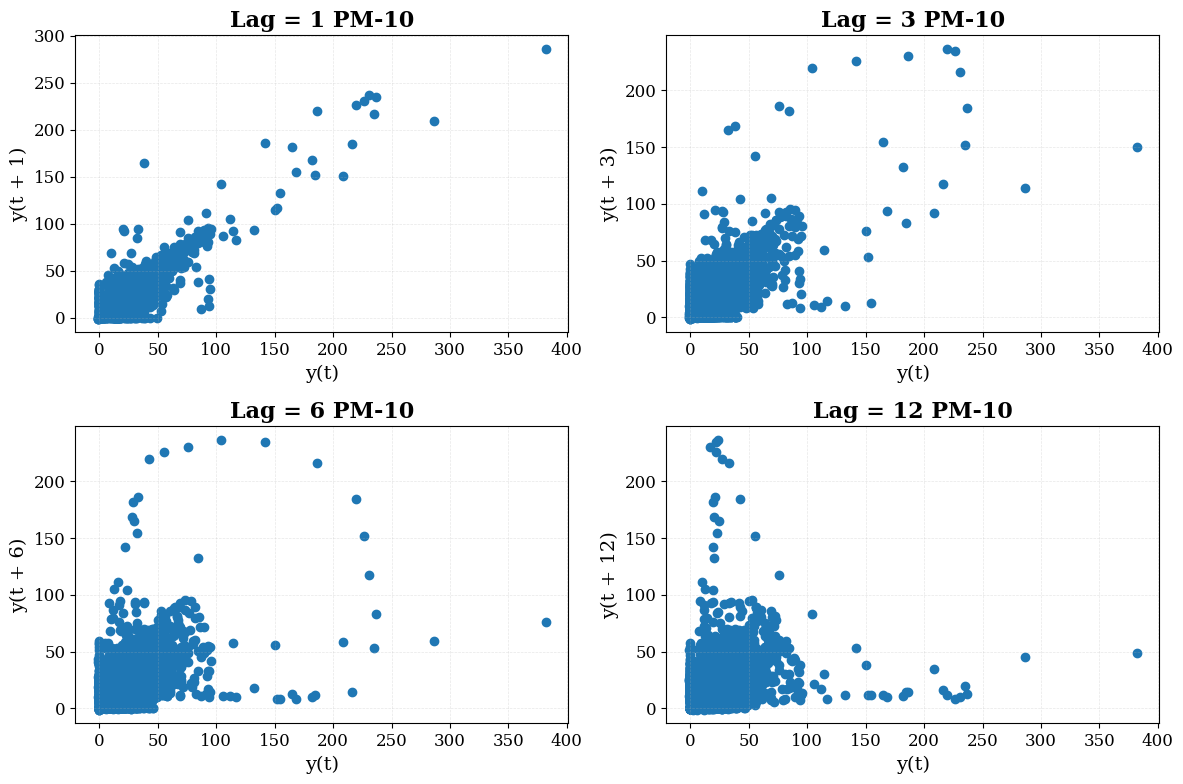

In [63]:
numcol = ['CO', 'NO2', 'PM-10']  # plot lag plots for each pollutant..
for col in numcol:
  plot_lag_plots(mydit, col, lags=[1, 3, 6, 12])

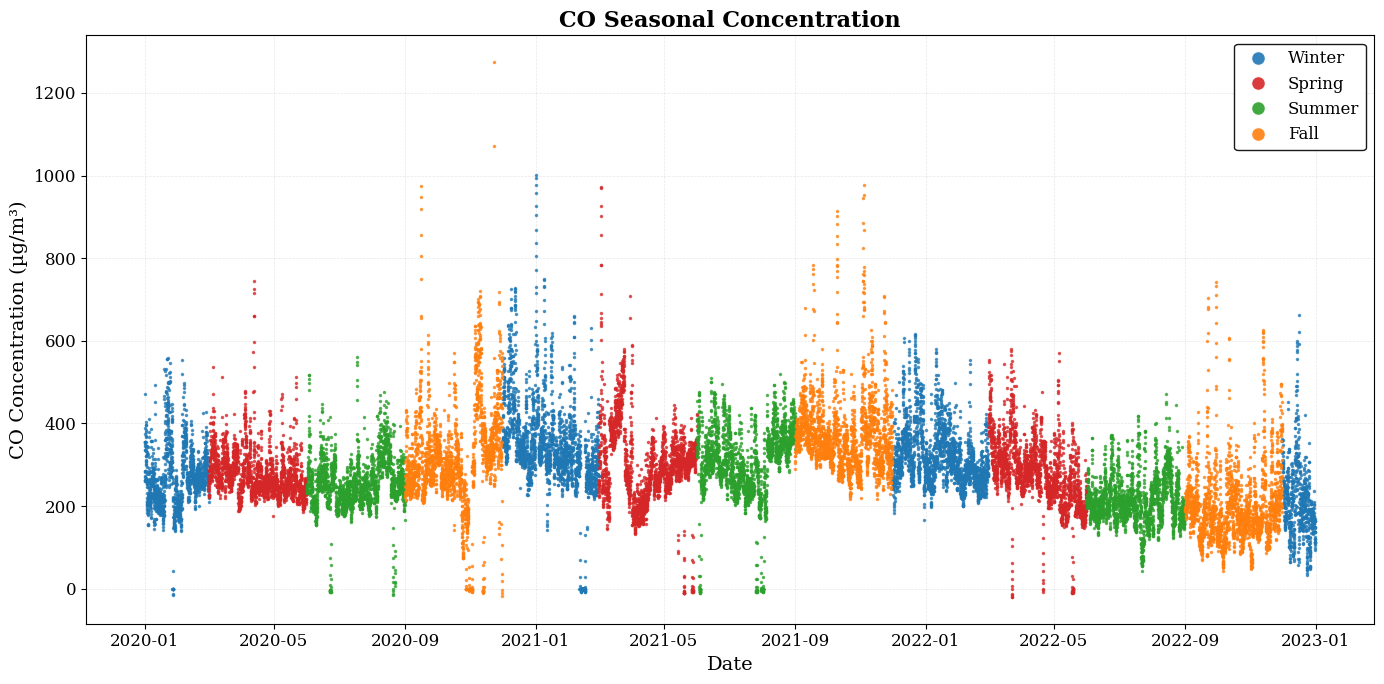

In [64]:

def plot_time_series_by_season(data, col):
    plt.figure(figsize=(14, 7))
    season_order = ['winter', 'spring', 'summer', 'fall']   # Adjust if your season names differ
    colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']   # custom colors for better visibility
    handles = []
    for season, color in zip(season_order, colors):
        mask = data['season'] == season
        plt.plot(data.index[mask], data[col][mask], '.', label=season.capitalize(), color=color, alpha=0.7, markersize=3)
        handles.append(Line2D([0], [0], marker='o', color='w', label=season.capitalize(),
                              markerfacecolor=color, markersize=10, alpha=0.9))
    plt.title(f"{col} Seasonal Concentration", fontsize=16)
    plt.xlabel("Date", fontsize=14)
    plt.ylabel(f"{col} Concentration (µg/m³)", fontsize=14)
    plt.legend(handles=handles)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_time_series_by_season(mydit, "CO")

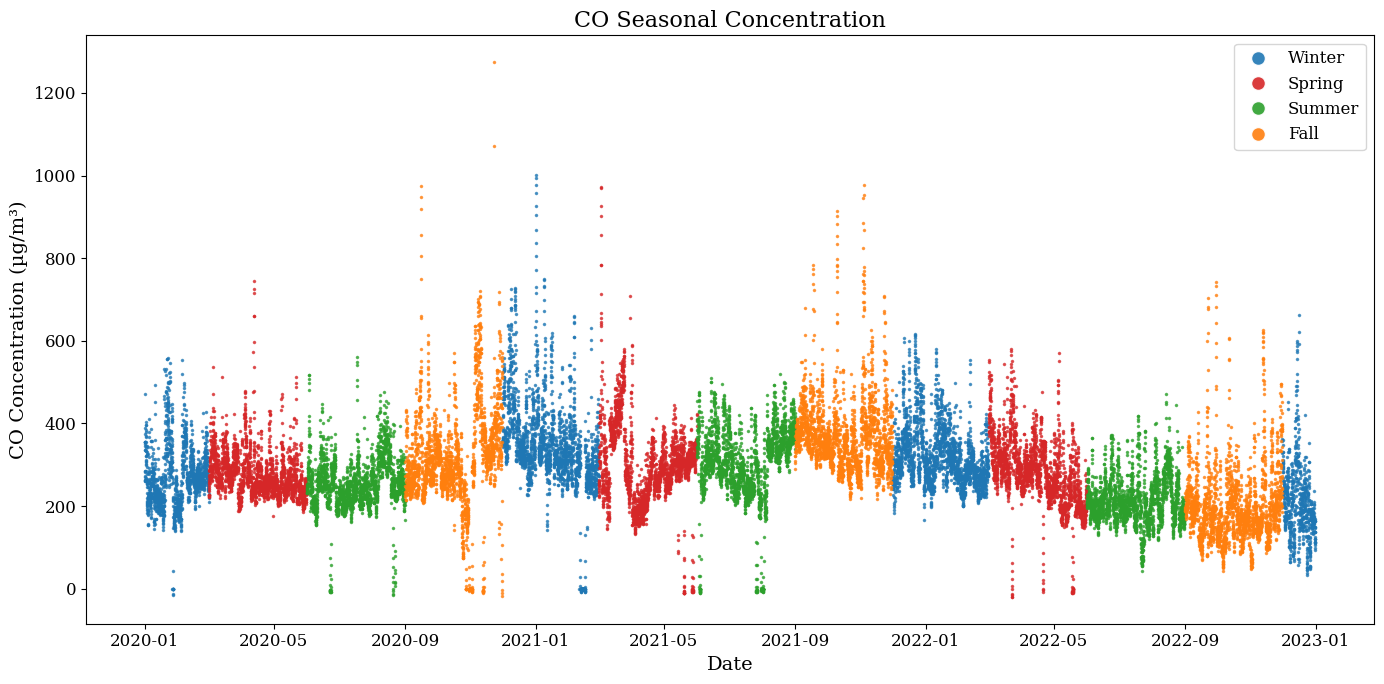

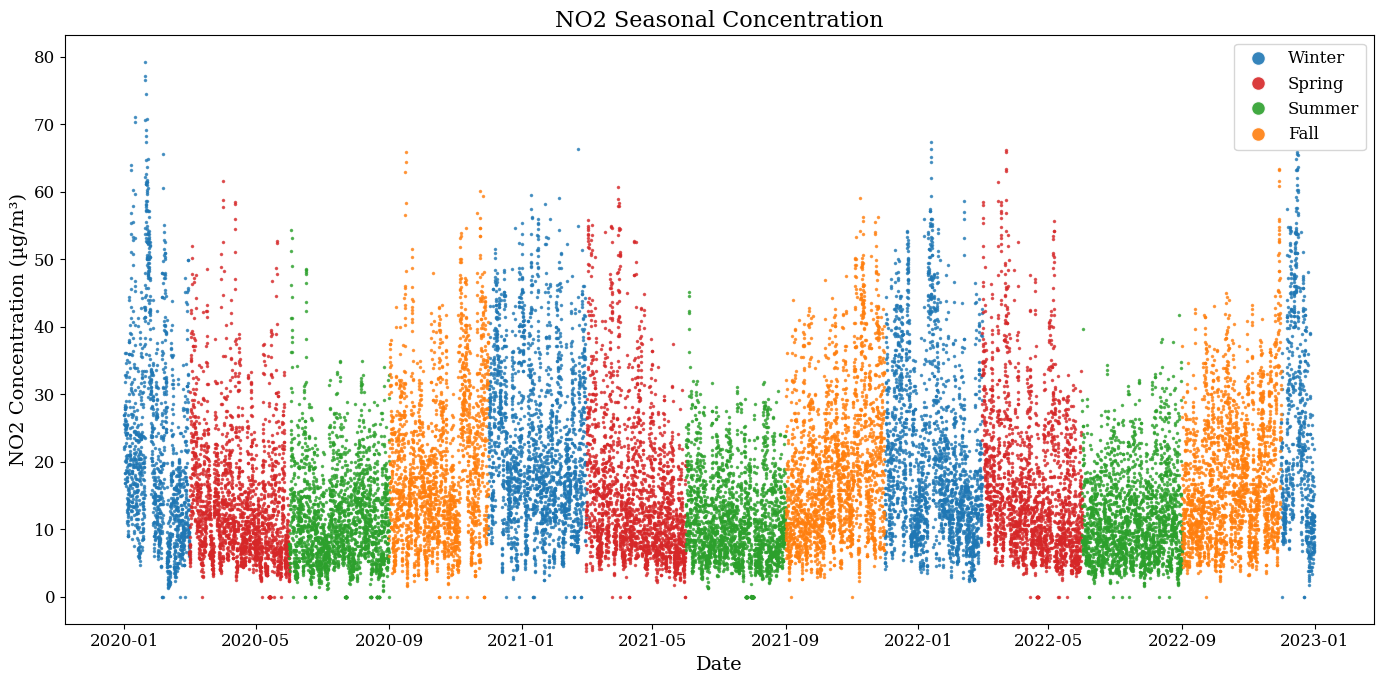

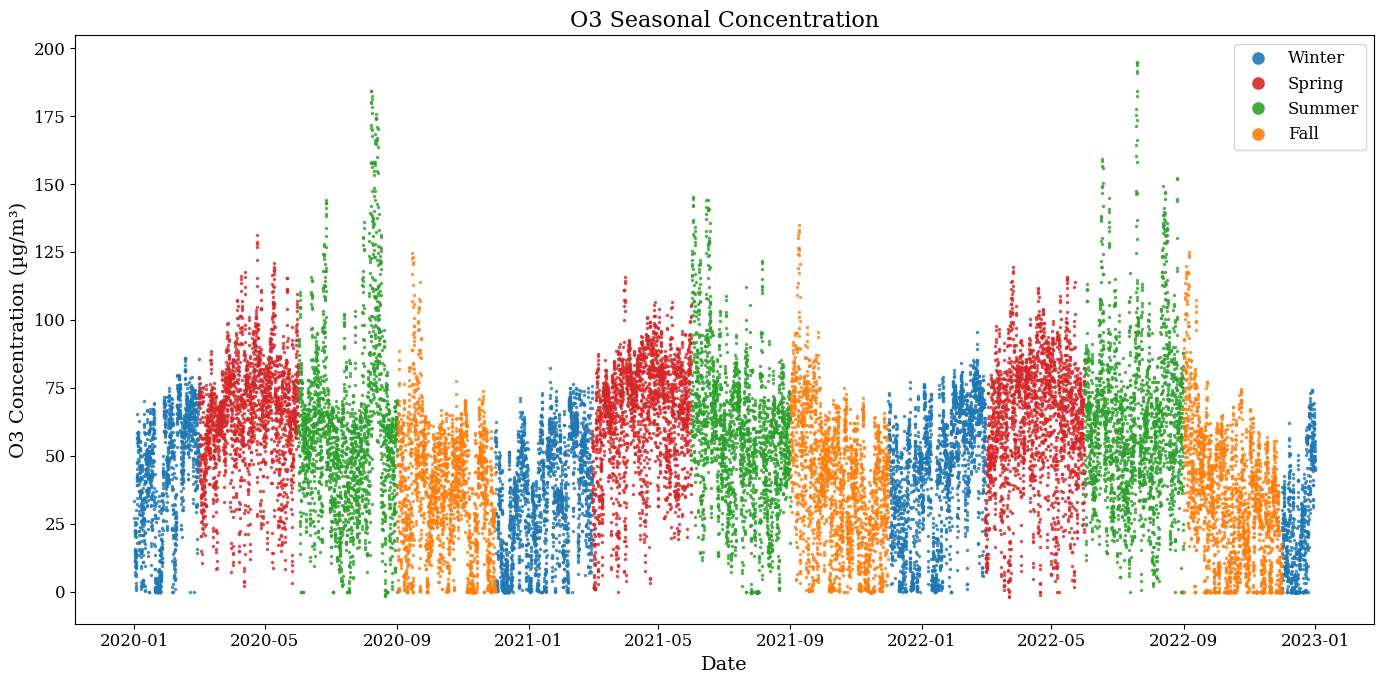

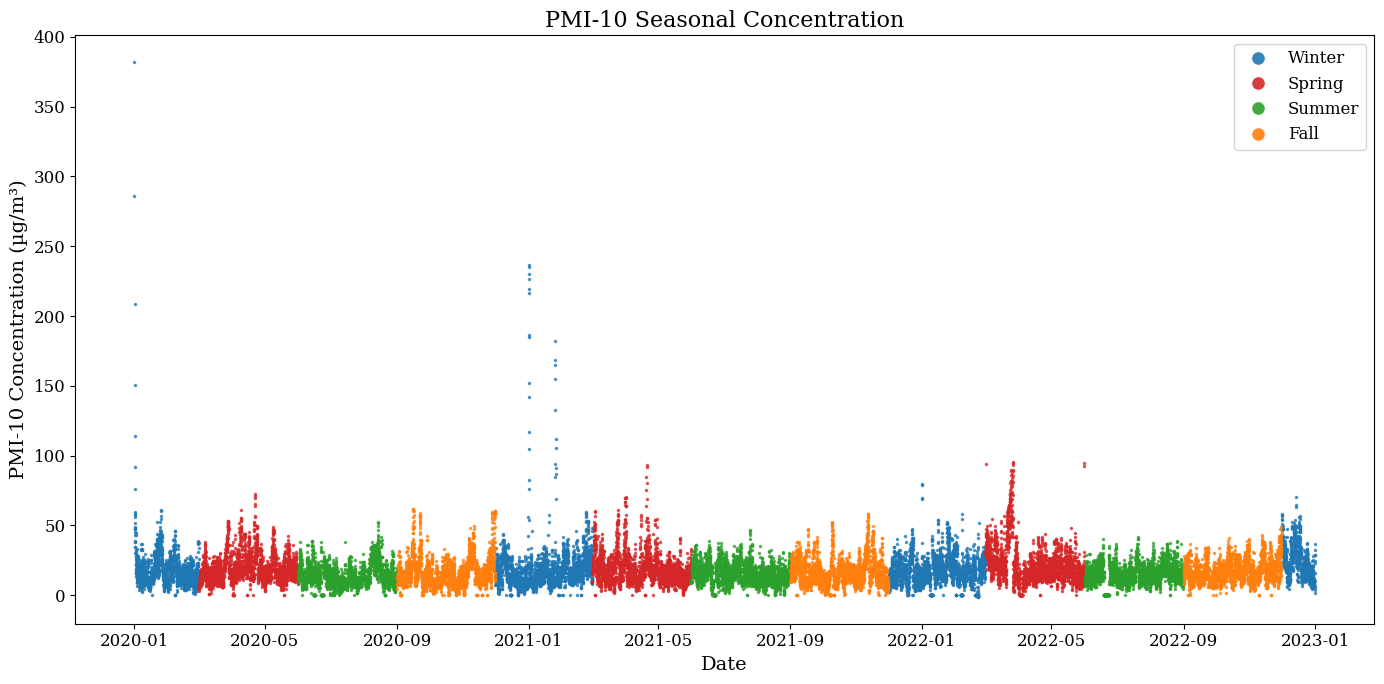

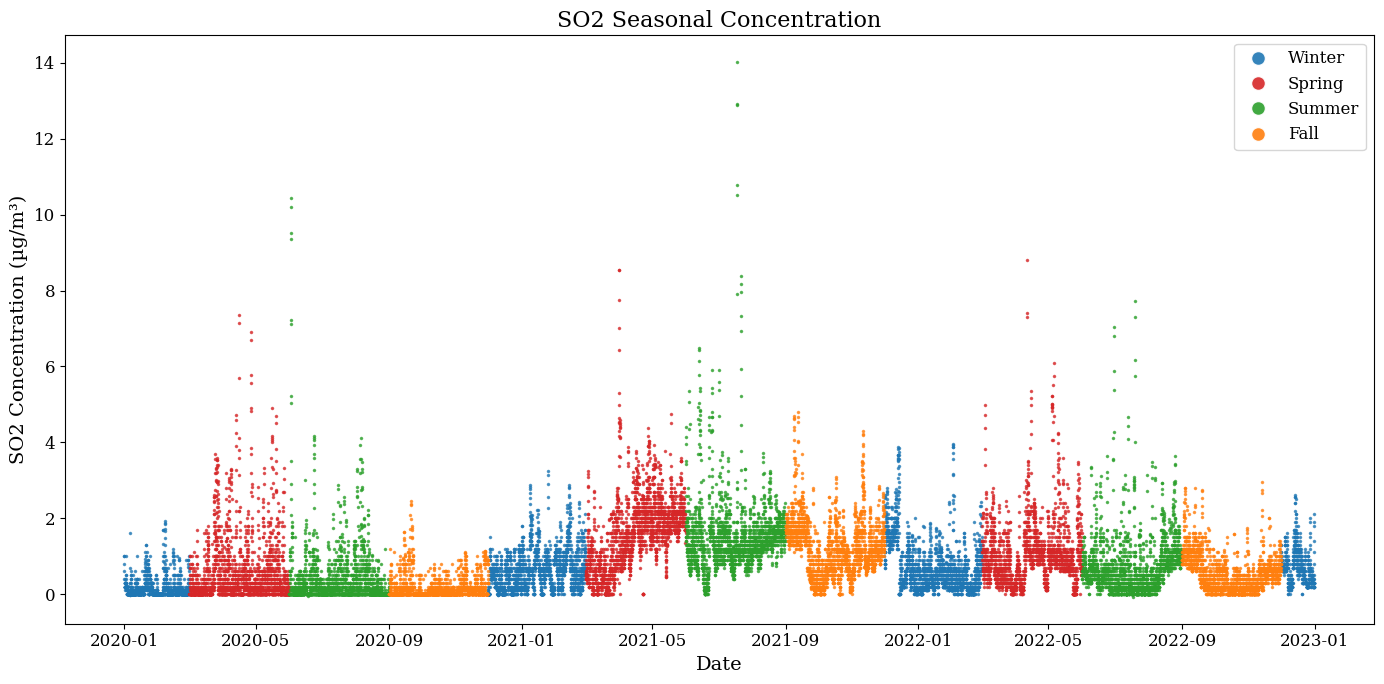

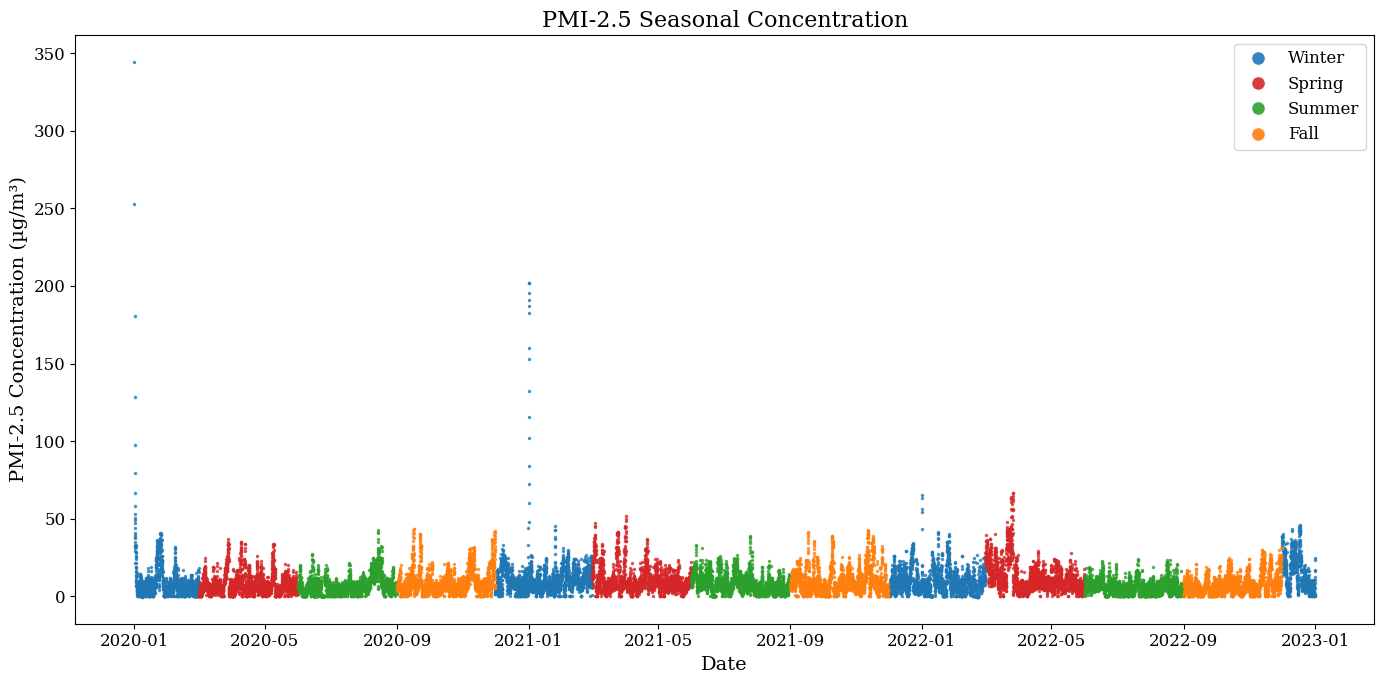

In [83]:
numcol = ['CO', 'NO2', 'O3', 'PMI-10', 'SO2', 'PMI-2.5']  # plot lag plots for each pollutant..
for col in numcol:
  plot_time_series_by_season(mydit, col)

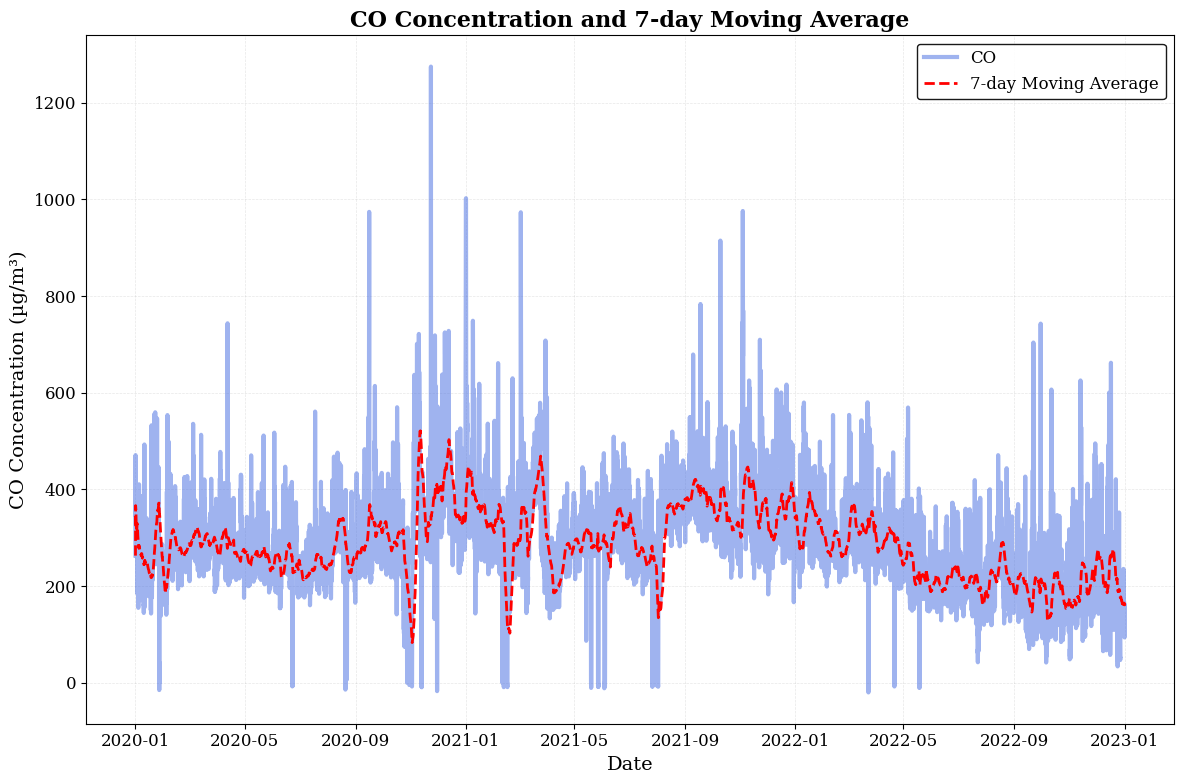

In [65]:
# Ensure the index is datetime (should already be, but just in case)
def plot_moving_average(data, col, window=7):
    data = data.copy()
    data.index = pd.to_datetime(data.index)
    data[f'{col}_ma'] = data[col].rolling(window=window*24, min_periods=1).mean()  # 24*window for hourly data
    plt.figure(figsize=(12, 8))
    plt.plot(data.index, data[col], label=col, color='royalblue', alpha=0.5)
    plt.plot(data.index, data[f'{col}_ma'], label=f'{window}-day Moving Average', color='red', linestyle='--', linewidth=2)
    plt.title(f'{col} Concentration and {window}-day Moving Average', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel(f'{col} Concentration (µg/m³)', fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_moving_average(mydit, "CO", window=7)

In [66]:
def plot_moving_averages_subplots(data, cols, window=7):
    """
    Plots moving averages for multiple columns as subplots.

    Parameters:
    - data: pandas DataFrame with datetime index
    - cols: list of column names to plot
    - window: number of days for moving average (assumes hourly data)
    """
    data = data.copy()
    data.index = pd.to_datetime(data.index)
    fig, axes = plt.subplots(len(cols), 1, figsize=(12, 4 * len(cols)), sharex=True)

    for i, col in enumerate(cols):
        ma_col = f'{col}_ma'
        data[ma_col] = data[col].rolling(window=window * 24, min_periods=1).mean()

        ax = axes[i] if len(cols) > 1 else axes
        ax.plot(data.index, data[col], label=col, color='royalblue', alpha=0.5)
        ax.plot(data.index, data[ma_col], label=f'{window}-day MA', color='red', linestyle='--', linewidth=2)
        # ax.set_title(f'{col} Concentration and {window}-day Moving Average', fontsize=14)
        ax.set_ylabel(f'{col} (µg/m³)', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.xlabel('Date', fontsize=12)
    plt.tight_layout()
    plt.show()

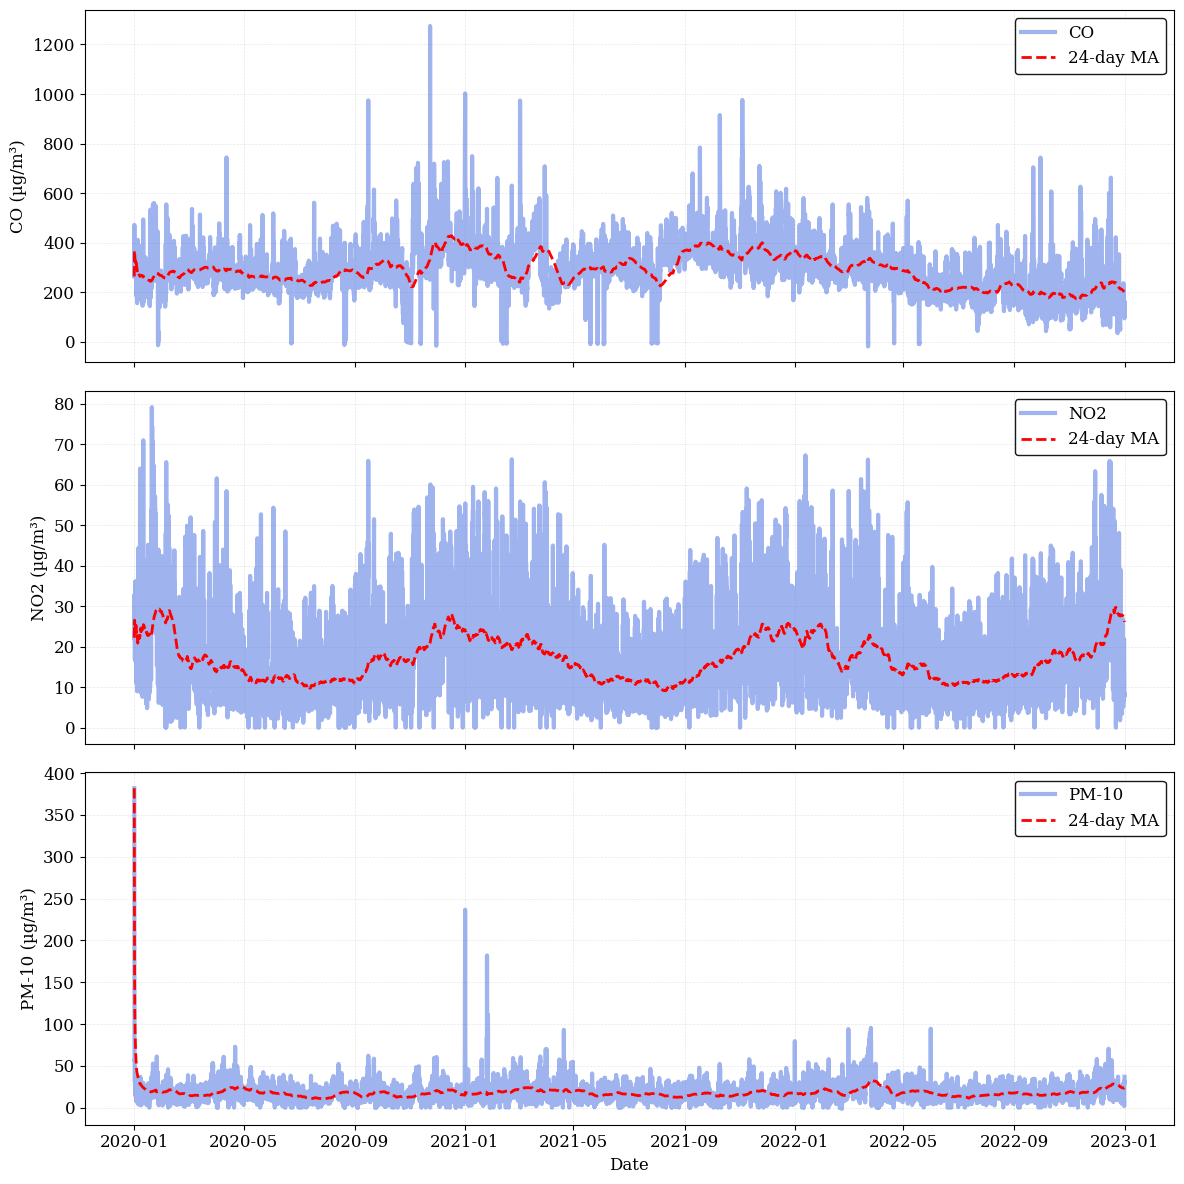

In [68]:
numcol = ['CO', 'NO2', 'PM-10'] 
plot_moving_averages_subplots(mydit, numcol, window=24)

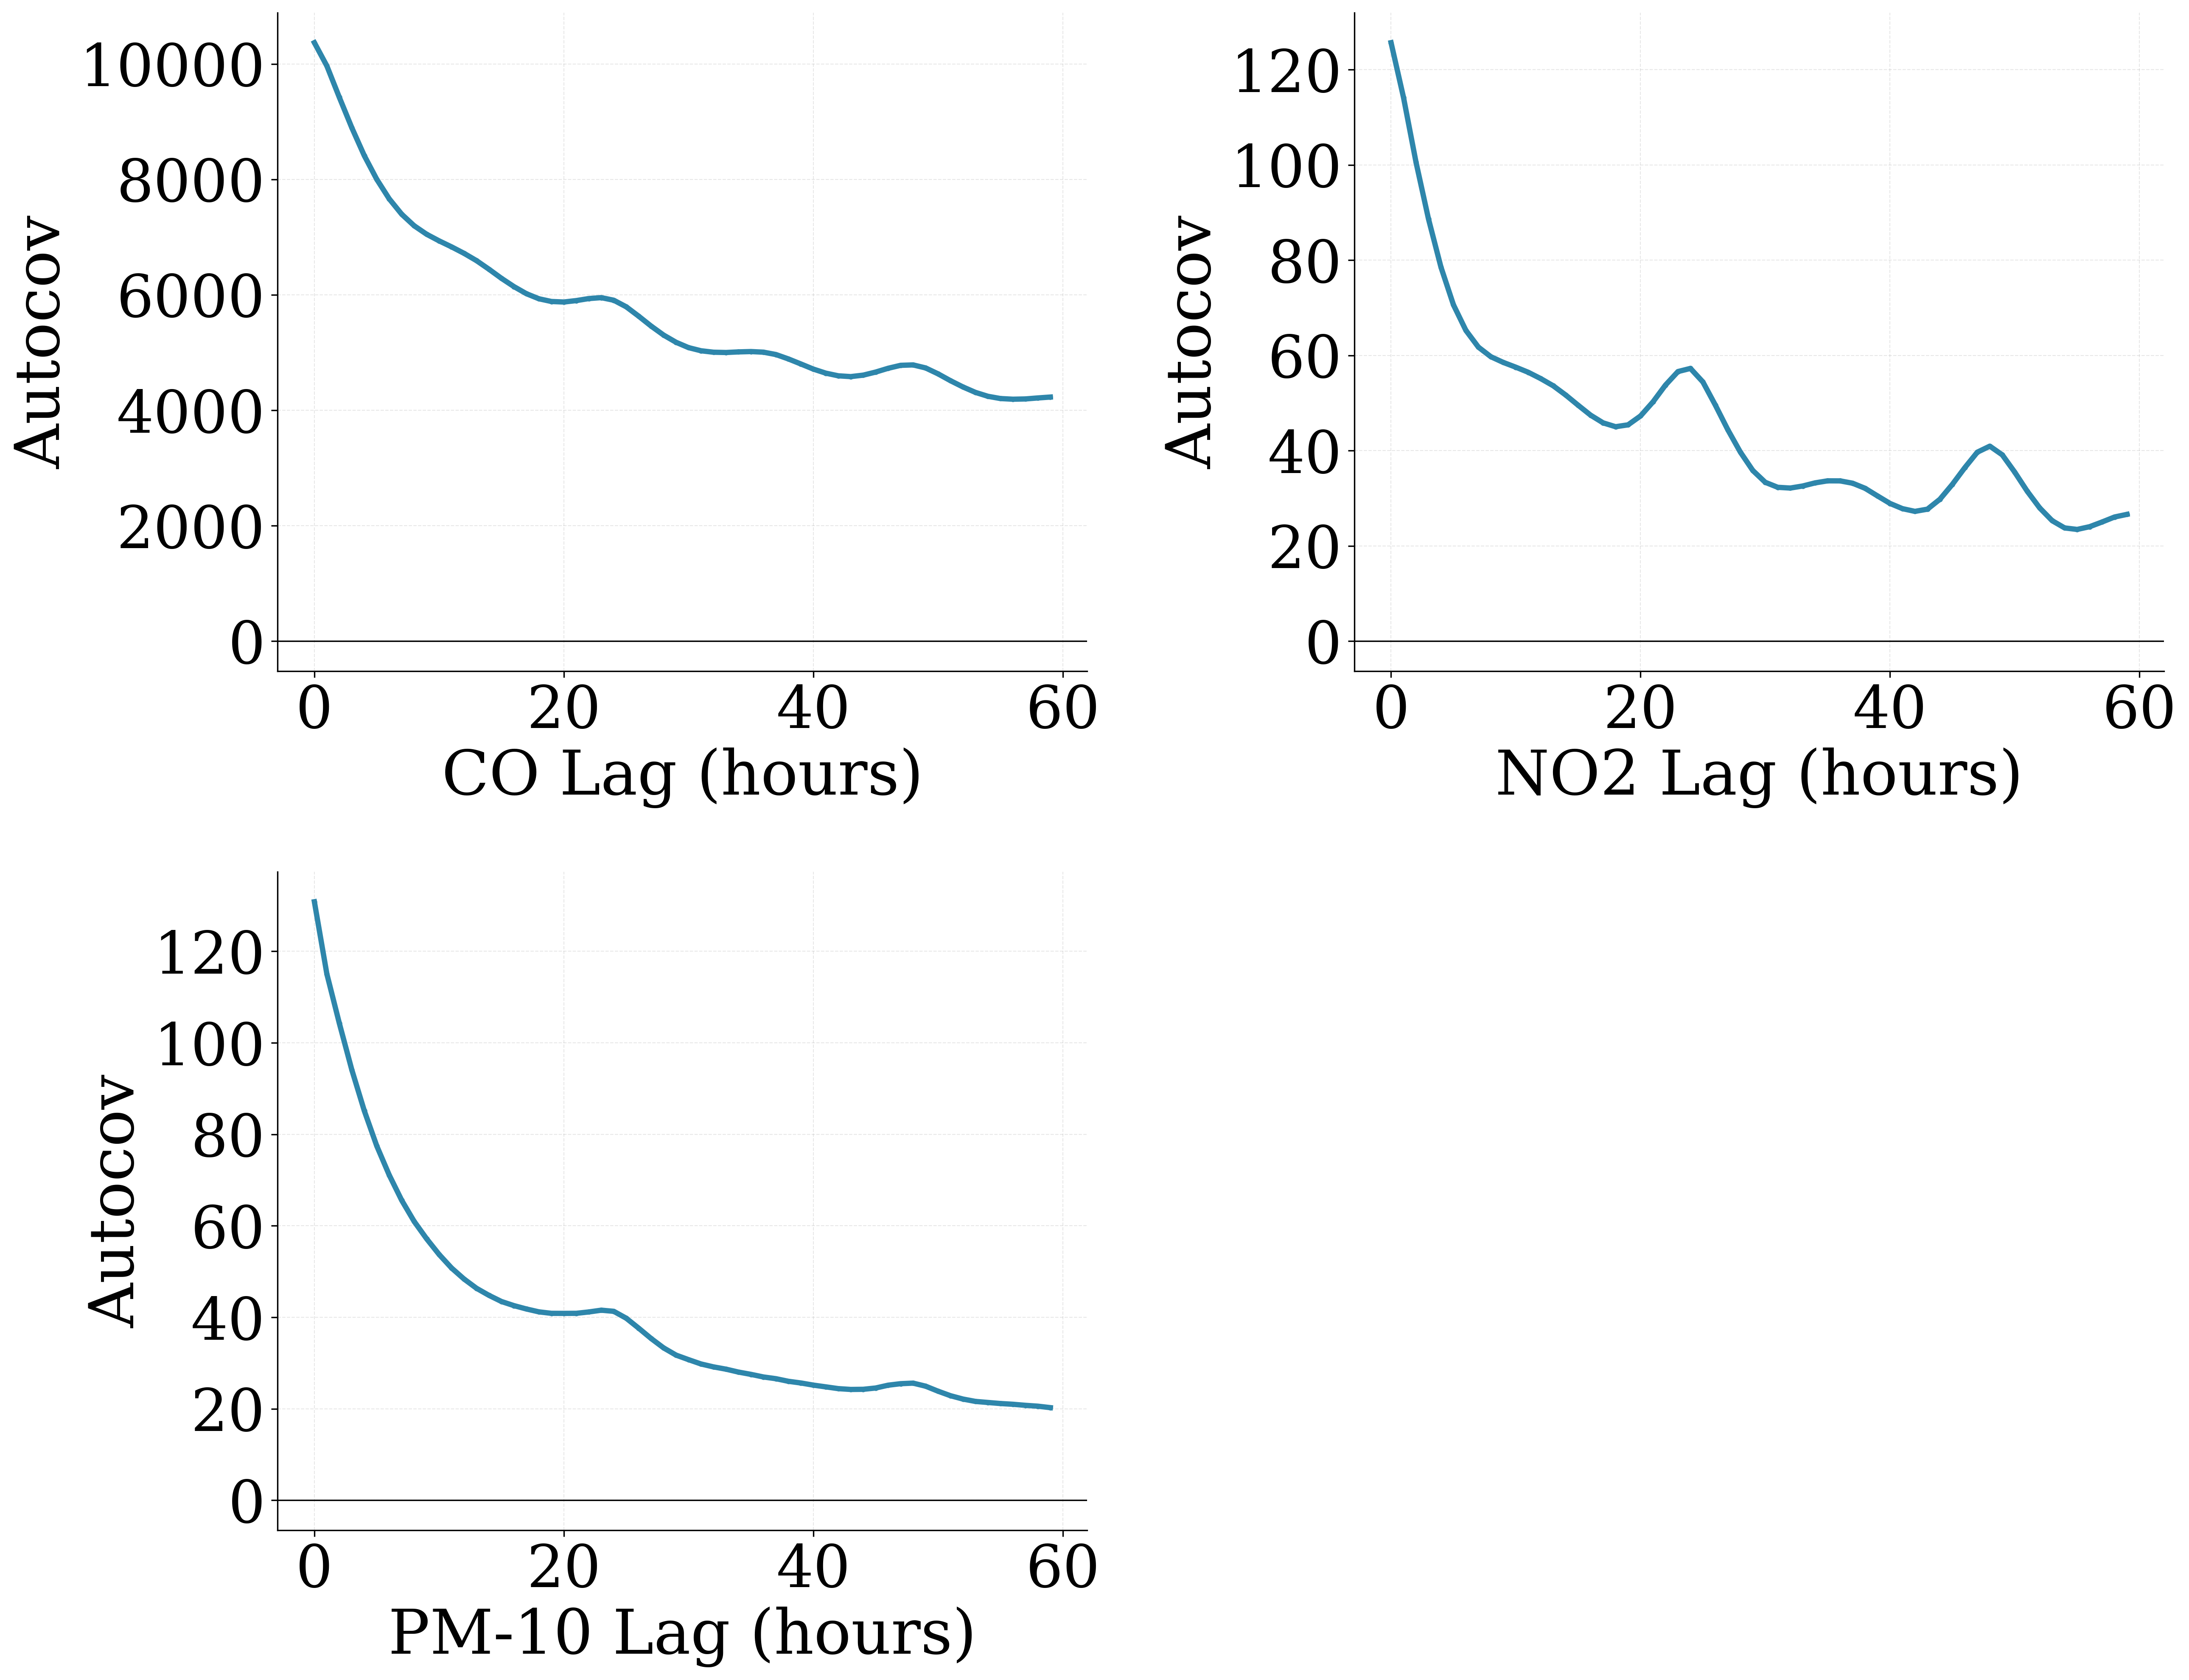

In [70]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acovf
import pandas as pd
import numpy as np

def autocovariance_subplots(data, columns, save_path=None,  lag_value=60):
    """
    Create publication-ready autocovariance subplots in 2x2 grid.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        Input data with time series
    columns : list
        List of column names to plot (maximum 3)
    lag_value : int
        Maximum lag to display (default: 60)
    """
    # Limit to maximum 3 subplots for 2x2 grid
    if len(columns) > 3:
        columns = columns[:3]
    
    data = data.copy()
    if not isinstance(data.index, pd.DatetimeIndex):
        data.index = pd.to_datetime(data.index)
    data = data.asfreq('h')

    # Create 2x2 subplot grid
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14), dpi=300)
    axes = axes.flatten()

    for i, col in enumerate(columns):
        # Calculate autocovariance
        autocov = acovf(data[col], fft=True, demean=True)
        lags = range(len(autocov))

        # Create plot
        axes[i].plot(lags[:lag_value], autocov[:lag_value], 
                    marker='o', markersize=2, linestyle='-', 
                    color='#2E86AB', linewidth=3)
        
        # Labels
        # axes[i].set_title(f fontsize=14, fontweight='bold', pad=10)
        axes[i].set_xlabel(f"{col} Lag (hours)", fontsize=35)
        axes[i].set_ylabel("Autocov", fontsize=35)
        
        # Formatting
        axes[i].grid(True, linestyle='--', alpha=0.3)
        axes[i].axhline(0, color='black', linewidth=0.8)
        
        # Tick parameters with large font sizes
        axes[i].tick_params(axis='both', which='major', labelsize=11)
        
        # Apply large font sizes to tick labels
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontsize(33)
            label.set_fontweight('normal')
            label.set_rotation(0)
        
        # Set x-ticks
        x_ticks = np.arange(0, lag_value + 1, 20)
        axes[i].set_xticks(x_ticks)
        
        # Clean spines
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

    # Hide the last unused subplot (4th one in 2x2 grid)
    if len(columns) < 4:
        fig.delaxes(axes[3])

    plt.tight_layout(pad=3.0)
    if save_path:
        ai.plt.savefig(f"{save_path}.pdf", format='pdf', bbox_inches='tight', dpi=600)
        ai.plt.show()
    plt.show()
    
    return fig, axes

# Usage
fig, axes = autocovariance_subplots(mydit, ['CO', 'NO2', 'PM-10'])

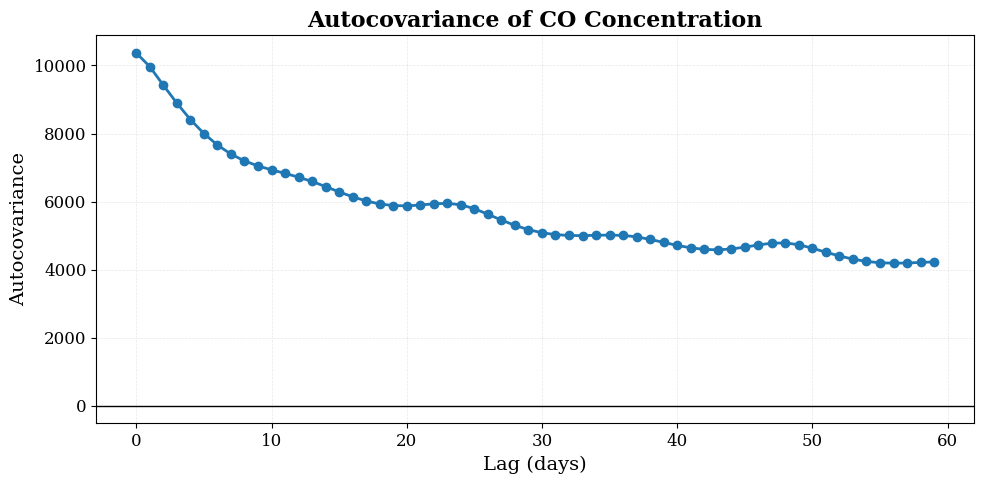

In [72]:


#Calculate and plot the autocovariance function
def autocovariance_plot(data, col, lag_value):
    data = data.copy()
    if not isinstance(data.index, pd.DatetimeIndex):  # ensure that the index is datetime
        data.index = pd.to_datetime(data.index)
    data = data.asfreq('h')  # enforce hourly frequency
    autocov = acovf(data[col], fft=True, demean=True)
    lags = range(len(autocov))
    plt.figure(figsize=(10, 5))
    plt.plot(lags[:lag_value], autocov[:lag_value], marker='o', linestyle='-', color='tab:blue', linewidth=2)

    plt.title(f"Autocovariance of {col} Concentration", fontsize=16)
    plt.xlabel("Lag (days)", fontsize=14)
    plt.ylabel("Autocovariance", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.axhline(0, color='black', linewidth=1)  # Reference line
    plt.tight_layout()
    plt.show()
autocovariance_plot(mydit, "CO", 60)


In [75]:


def acf_pacf_subplots(data, columns, lags=60, ncols=2):
    n = len(columns)
    nrows = (n + ncols - 1) // ncols

    fig, axes = ai.plt.subplots(nrows=nrows * 2, ncols=ncols, figsize=(6 * ncols, 2.5 * nrows * 2))
    axes = axes.reshape(nrows * 2, ncols)

    for i, col in enumerate(columns):
        row = i // ncols
        col_pos = i % ncols

        # ACF
        ai.plot_acf(data[col].dropna(), lags=lags, ax=axes[row * 2][col_pos], title=f"ACF: {col}")
        axes[row * 2][col_pos].spines['top'].set_visible(False)
        axes[row * 2][col_pos].spines['right'].set_visible(False)

        # PACF
        ai.plot_pacf(data[col].dropna(), lags=lags, ax=axes[row * 2 + 1][col_pos], title=f"PACF: {col}")
        axes[row * 2 + 1][col_pos].spines['top'].set_visible(False)
        axes[row * 2 + 1][col_pos].spines['right'].set_visible(False)

    ai.plt.tight_layout()
    ai.plt.show()

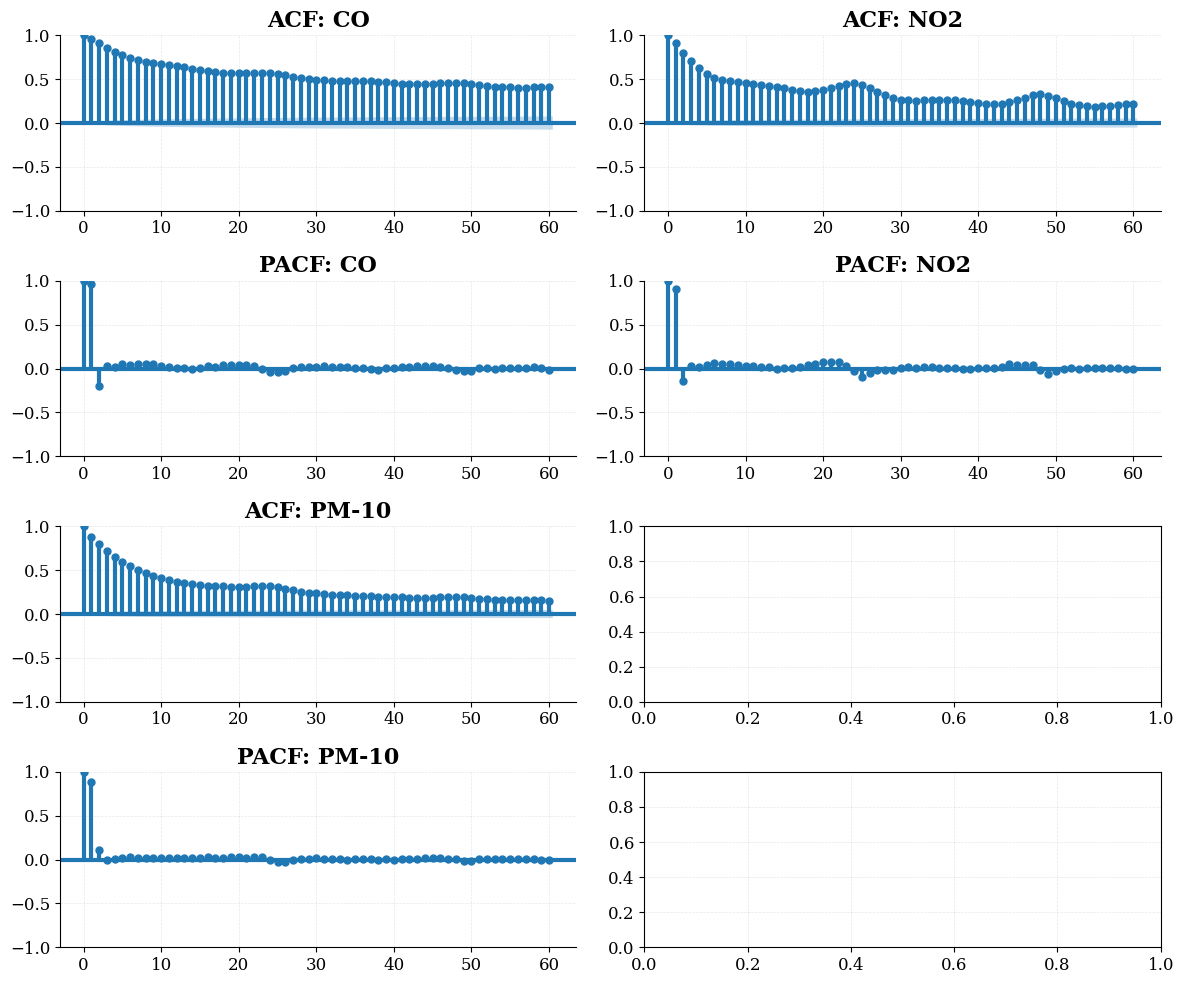

In [76]:
numcol = ['CO', 'NO2','PM-10']
acf_pacf_subplots(mydit, numcol, lags=60, ncols=2)


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

def plot_acf_pacf(data, col, lags=60, save_path=None):
    fig, axes = ai.plt.subplots(1, 2, figsize=(25, 10))

    label_fontsize = 40
    tick_fontsize = 40
    tick_width = 5
    tick_length = 14

    # ACF plot
    plot_acf(data[col].dropna(), lags=lags, ax=axes[0], title='')
    axes[0].set_xlabel("Lag", fontsize=label_fontsize)
    axes[0].set_ylabel("ACF(NO₂)", fontsize=label_fontsize)

    # PACF plot
    plot_pacf(data[col].dropna(), lags=lags, ax=axes[1], title='')
    axes[1].set_xlabel("Lag", fontsize=label_fontsize)
    axes[1].set_ylabel("PACF (NO₂)", fontsize=label_fontsize)

    # Tick styling
    for ax in axes:
        ax.tick_params(axis='both', labelsize=tick_fontsize, width=tick_width, length=tick_length)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(tick_fontsize)
            label.set_fontweight('normal')
            label.set_rotation(0)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Save as PDF if path is provided
    if save_path:
        ai.plt.savefig(f"{save_path}.pdf", format='pdf', bbox_inches='tight', dpi=600)
    plt.show()

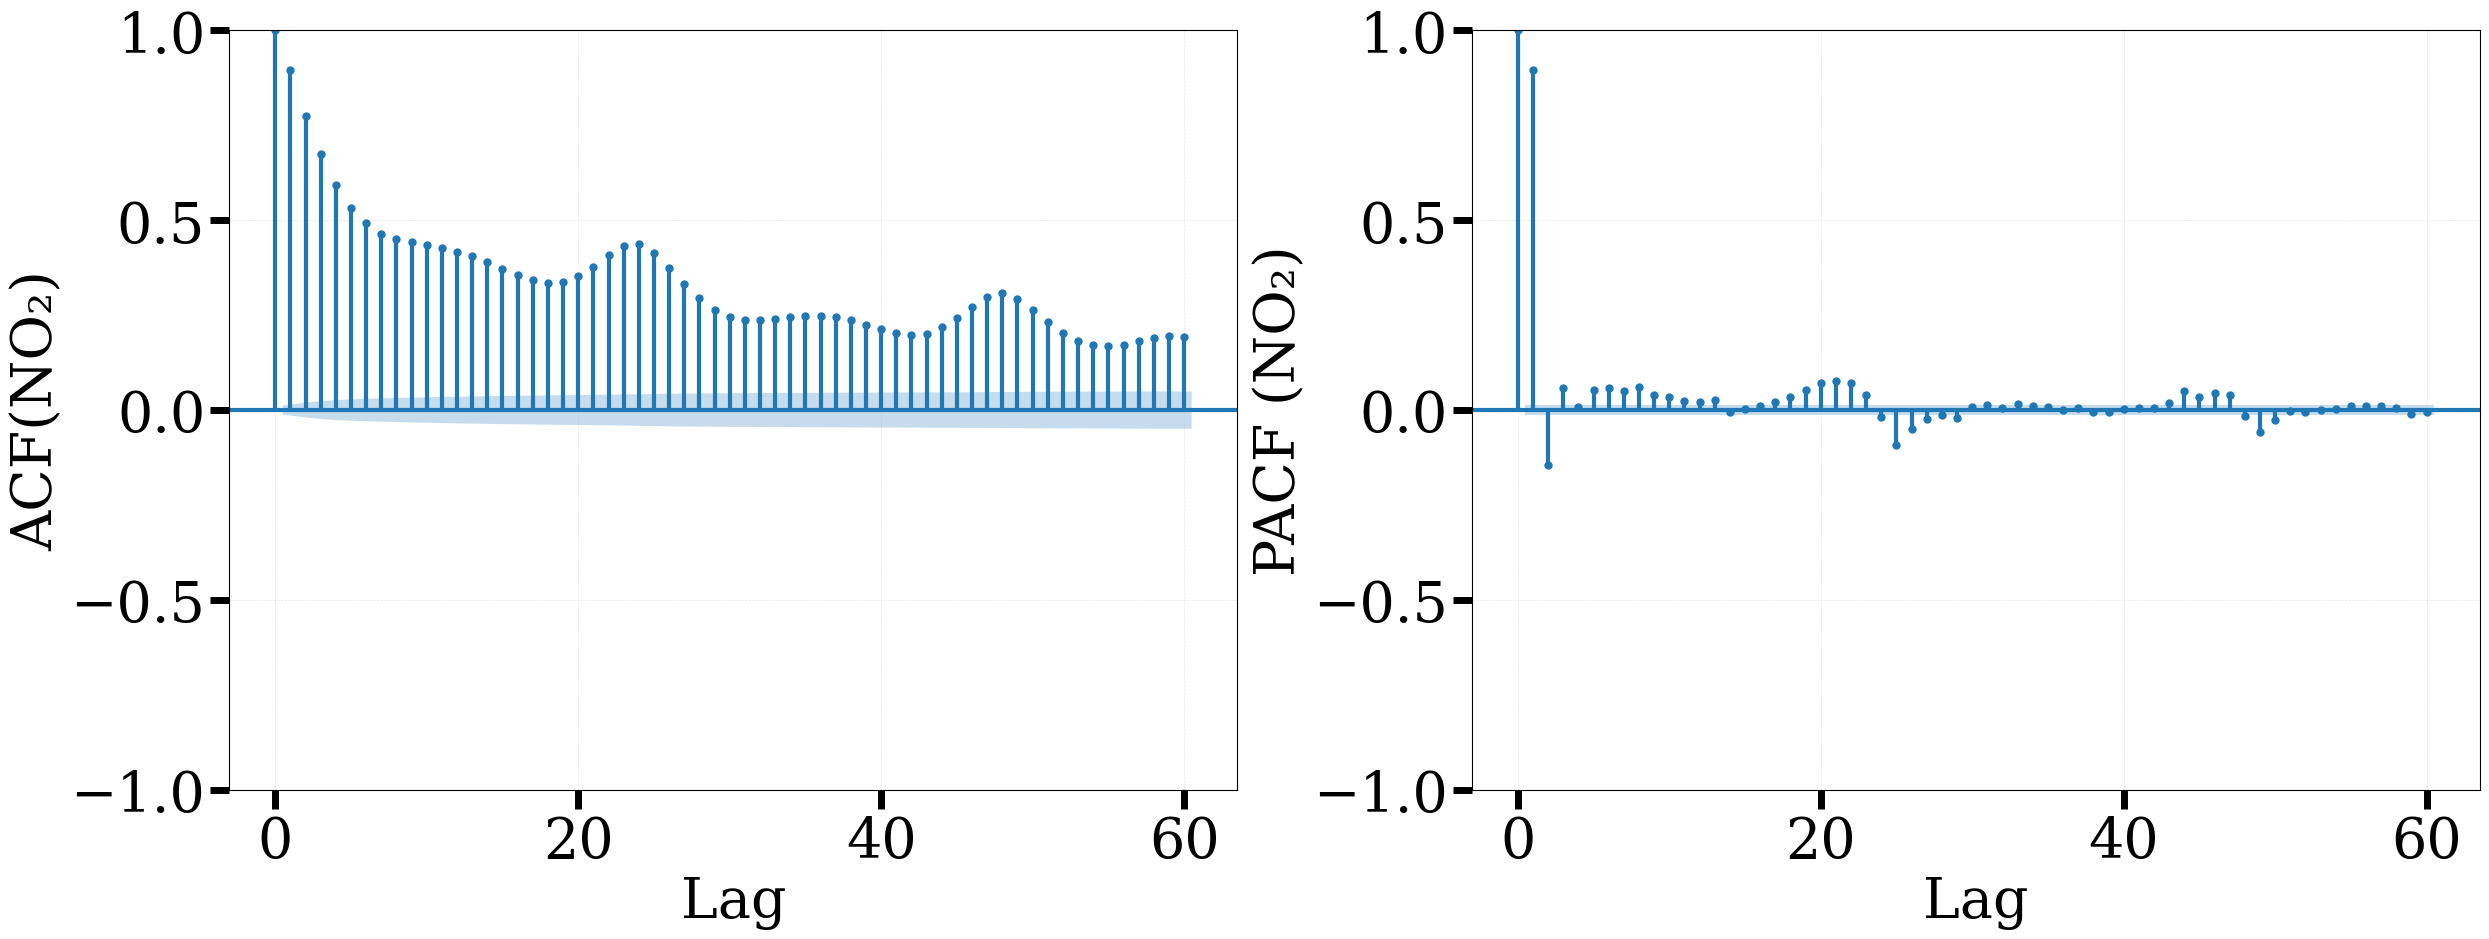

In [144]:
plot_acf_pacf(mydf, "NO2", lags=60, save_path="figures/pacf")

In [79]:
# Augmented Dickey-Fuller (ADF) Test for Stationarity

def adf_stationarity_test(series,  col, signif=0.5):
    series = series[col]
    result = ai.adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    for key, value in result[4].items():
        print(f'Critical Value ({key}): {value:.4f}')
    if result[1] < signif:
        print(f"=> Series for {col} is likely stationary (reject H0)")
    else:
        print(f"=> Series for {col} non-stationary (fail to reject H0)")

# Example for NO2
adf_stationarity_test(mydit, col="O3")


ADF Statistic: -9.8682
p-value: 0.0000
Critical Value (1%): -3.4306
Critical Value (5%): -2.8617
Critical Value (10%): -2.5668
=> Series for O3 is likely stationary (reject H0)


In [80]:
numcol = ['CO', 'NO2',  'PM-10']

import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import numpy as np

def adf_barplot(df, columns=None, signif=0.05):
    if columns is None:
        columns = df.columns

    adf_stats = []
    p_values = []
    labels = []

    for col in columns:
        series = df[col].dropna()
        if len(series) < 10:
            continue
        result = adfuller(series, autolag='AIC')
        adf_stats.append(result[0])
        p_values.append(result[1])
        labels.append(col)

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, adf_stats, width, label='ADF Statistic', color='steelblue')
    bars2 = ax.bar(x + width/2, p_values, width, label='p-value', color='orange')

    ax.axhline(signif, color='red', linestyle='--', label=f'Significance Threshold ({signif})')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel("Value")
    ax.set_title("ADF Test Statistics and p-values by Feature")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Optional: print summary
    for label, stat, p in zip(labels, adf_stats, p_values):
        status = "stationary" if p < signif else "non-stationary"
        print(f"{label}: ADF = {stat:.4f}, p = {p:.4f} → {status}")

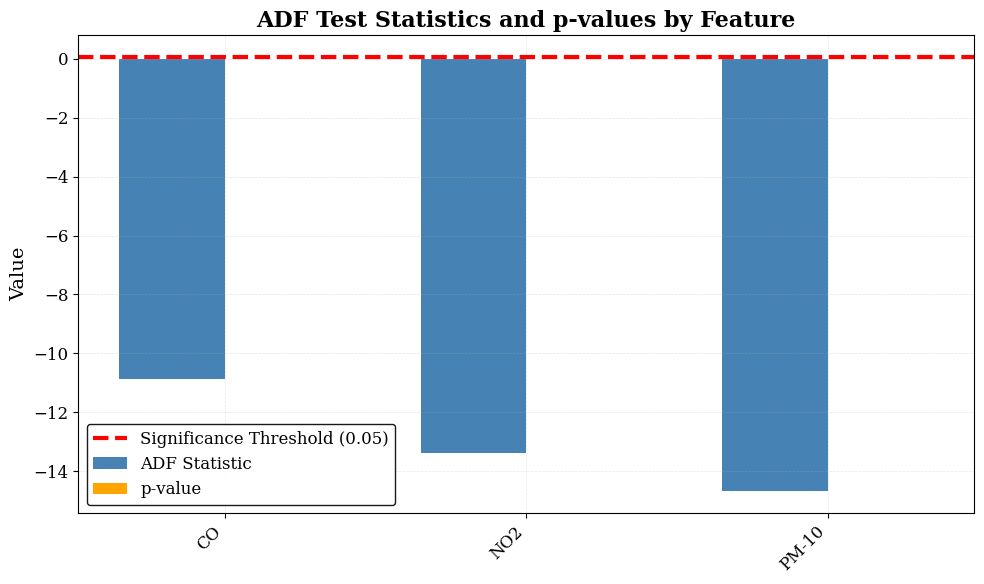

CO: ADF = -10.8803, p = 0.0000 → stationary
NO2: ADF = -13.3846, p = 0.0000 → stationary
PM-10: ADF = -14.6777, p = 0.0000 → stationary


In [81]:
adf_barplot(mydit, numcol, signif=0.05)

In [ ]:
numcol = ['CO', 'NO2','PM-10']  # perform stationairty test for each of the pollutants..
for col in numcol:
  adf_stationarity_test(mydit, col)
  print()
  print("-------------")

ADF Statistic: -10.8803
p-value: 0.0000
Critical Value (1%): -3.4306
Critical Value (5%): -2.8617
Critical Value (10%): -2.5668
=> Series for CO is likely stationary (reject H0)

-------------
ADF Statistic: -13.3846
p-value: 0.0000
Critical Value (1%): -3.4306
Critical Value (5%): -2.8617
Critical Value (10%): -2.5668
=> Series for NO2 is likely stationary (reject H0)

-------------
ADF Statistic: -14.6777
p-value: 0.0000
Critical Value (1%): -3.4306
Critical Value (5%): -2.8617
Critical Value (10%): -2.5668
=> Series for PM-10 is likely stationary (reject H0)

-------------


In [ ]:
mydit.to_csv("clean_data.csv", index=True) # save the clean datasets

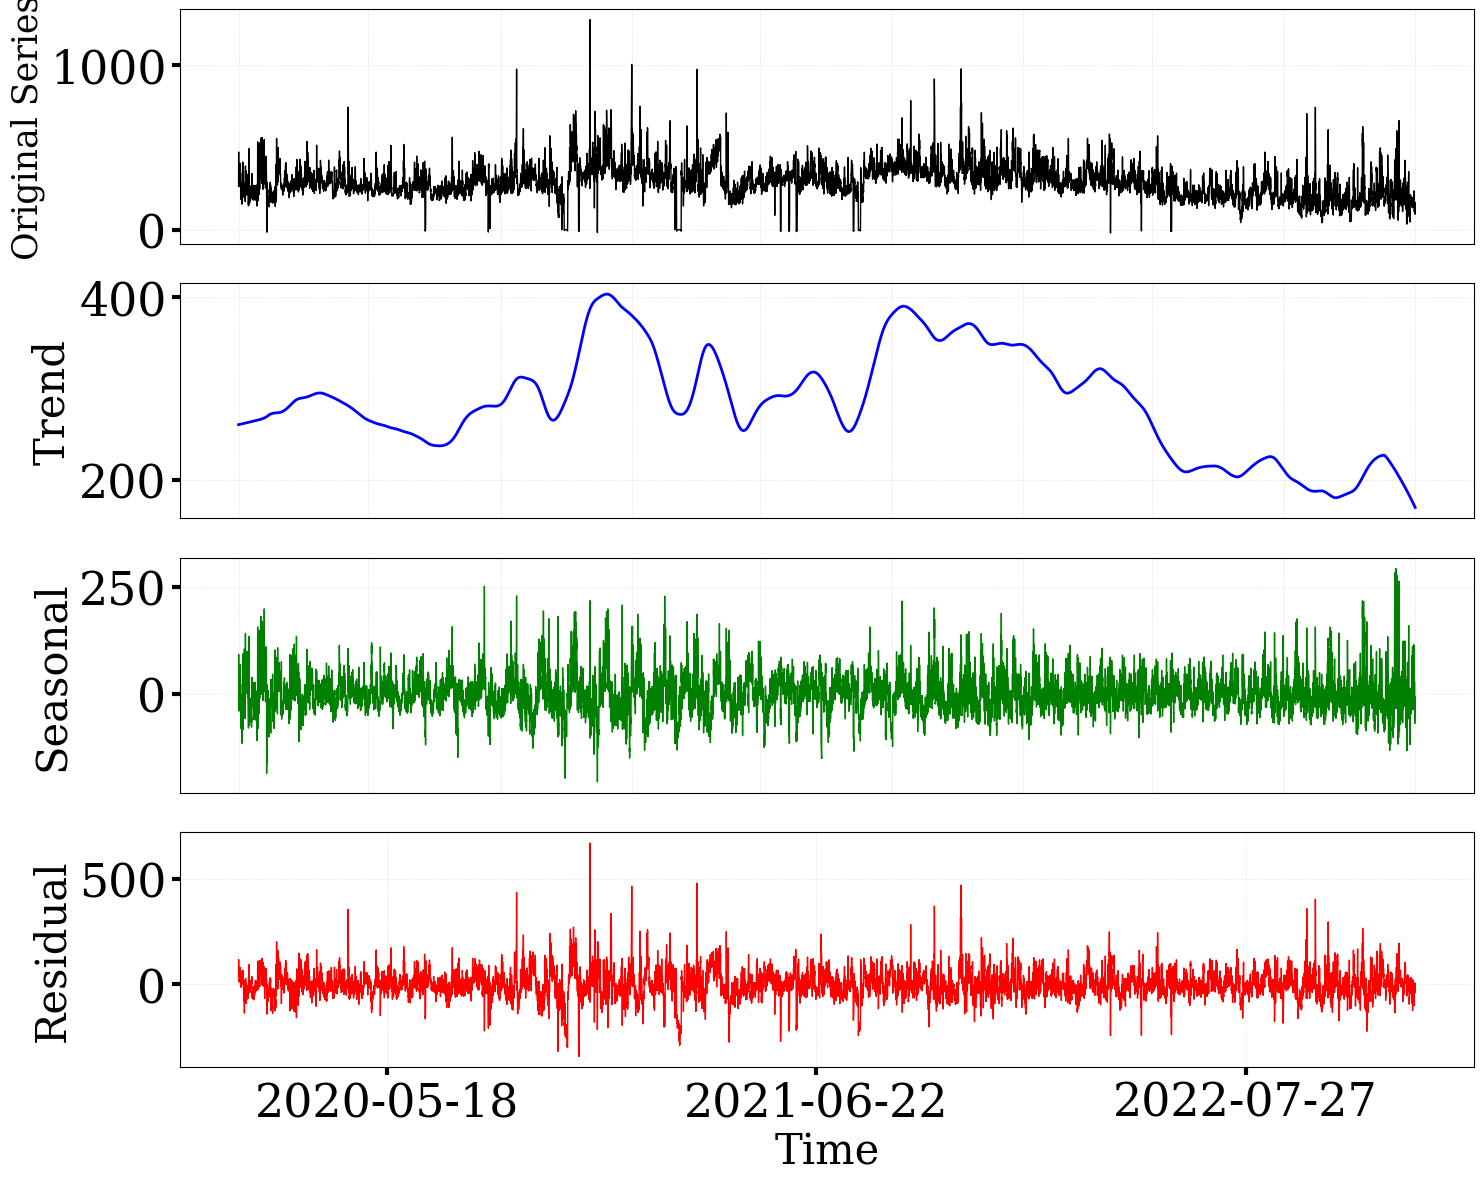

In [86]:
def STL_fit(data, col, save_path=None, period=24*30):  # assuming hourly data with monthly seasonality
    df = data.copy()

    if not isinstance(data.index, ai.pd.DatetimeIndex):
        df.index = ai.pd.to_datetime(data.index)
    df = df.asfreq('h')  # enforce hourly frequency

    stl = ai.STL(df[col], period=period)
    result = stl.fit()

    # Add components to dataframe
    df[col + "_trend"] = result.trend
    df[col + "_seasonal"] = result.seasonal
    df[col + "_resid"] = result.resid
    
    # Create decomposition plot
    fig, axes = plt.subplots(4, 1, figsize=(15, 12))
    
    # Original series
    axes[0].plot(df.index, df[col], color='black', linewidth=1)
    axes[0].set_ylabel('Original Series', fontsize=25)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticklabels([])  # Remove x-axis labels
    axes[0].tick_params(bottom=False)  # Remove x-axis ticks
    
    # Trend component
    axes[1].plot(df.index, result.trend, color='blue', linewidth=2)
    axes[1].set_ylabel('Trend', fontsize=30)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticklabels([])  # Remove x-axis labels
    axes[1].tick_params(bottom=False)  # Remove x-axis ticks
    
    # Seasonal component
    axes[2].plot(df.index, result.seasonal, color='green', linewidth=1)
    axes[2].set_ylabel('Seasonal', fontsize=30)
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xticklabels([])  # Remove x-axis labels
    axes[2].tick_params(bottom=False)  # Remove x-axis ticks
    
    # Residual component (only this one shows x-axis)
    axes[3].plot(df.index, result.resid, color='red', linewidth=1)
    axes[3].set_ylabel('Residual', fontsize=30)
    axes[3].set_xlabel('Time', fontsize=30)
    axes[3].grid(True, alpha=0.3)
    
    # Apply tick formatting to all axes
    for i, ax in enumerate(axes):
        ax.tick_params(axis='both', labelsize=33, width=3, length=6)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(33)
            label.set_fontweight('normal')
            label.set_rotation(0)
    
    # Reduce number of x-ticks on the last plot to avoid crowding
    axes[3].xaxis.set_major_locator(plt.MaxNLocator(4))  # Show only 6 x-ticks
    
    plt.tight_layout()
    if save_path:
        ai.plt.savefig(f"{save_path}.pdf", format='pdf', bbox_inches='tight', dpi=600)
        ai.plt.show()
    plt.show()
    
    return df, result

# Usage example
decomposed_data, stl_result = STL_fit(mydit, 'CO')